In [1]:
%config InlineBackend.figure_format = 'retina'

In [2]:
import concurrent
import time
import re

import astropy.units as u
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import numpy as np
import pyvo
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS

# Suppress logging temporarily to prevent astropy
# from repeatedly printing out warning notices related to alternate WCSs
import logging

logging.getLogger("astropy").setLevel(logging.ERROR)

In [3]:
%matplotlib inline

<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2581476/1953583141.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Wavelength [$\mu$m]", fontsize=13)


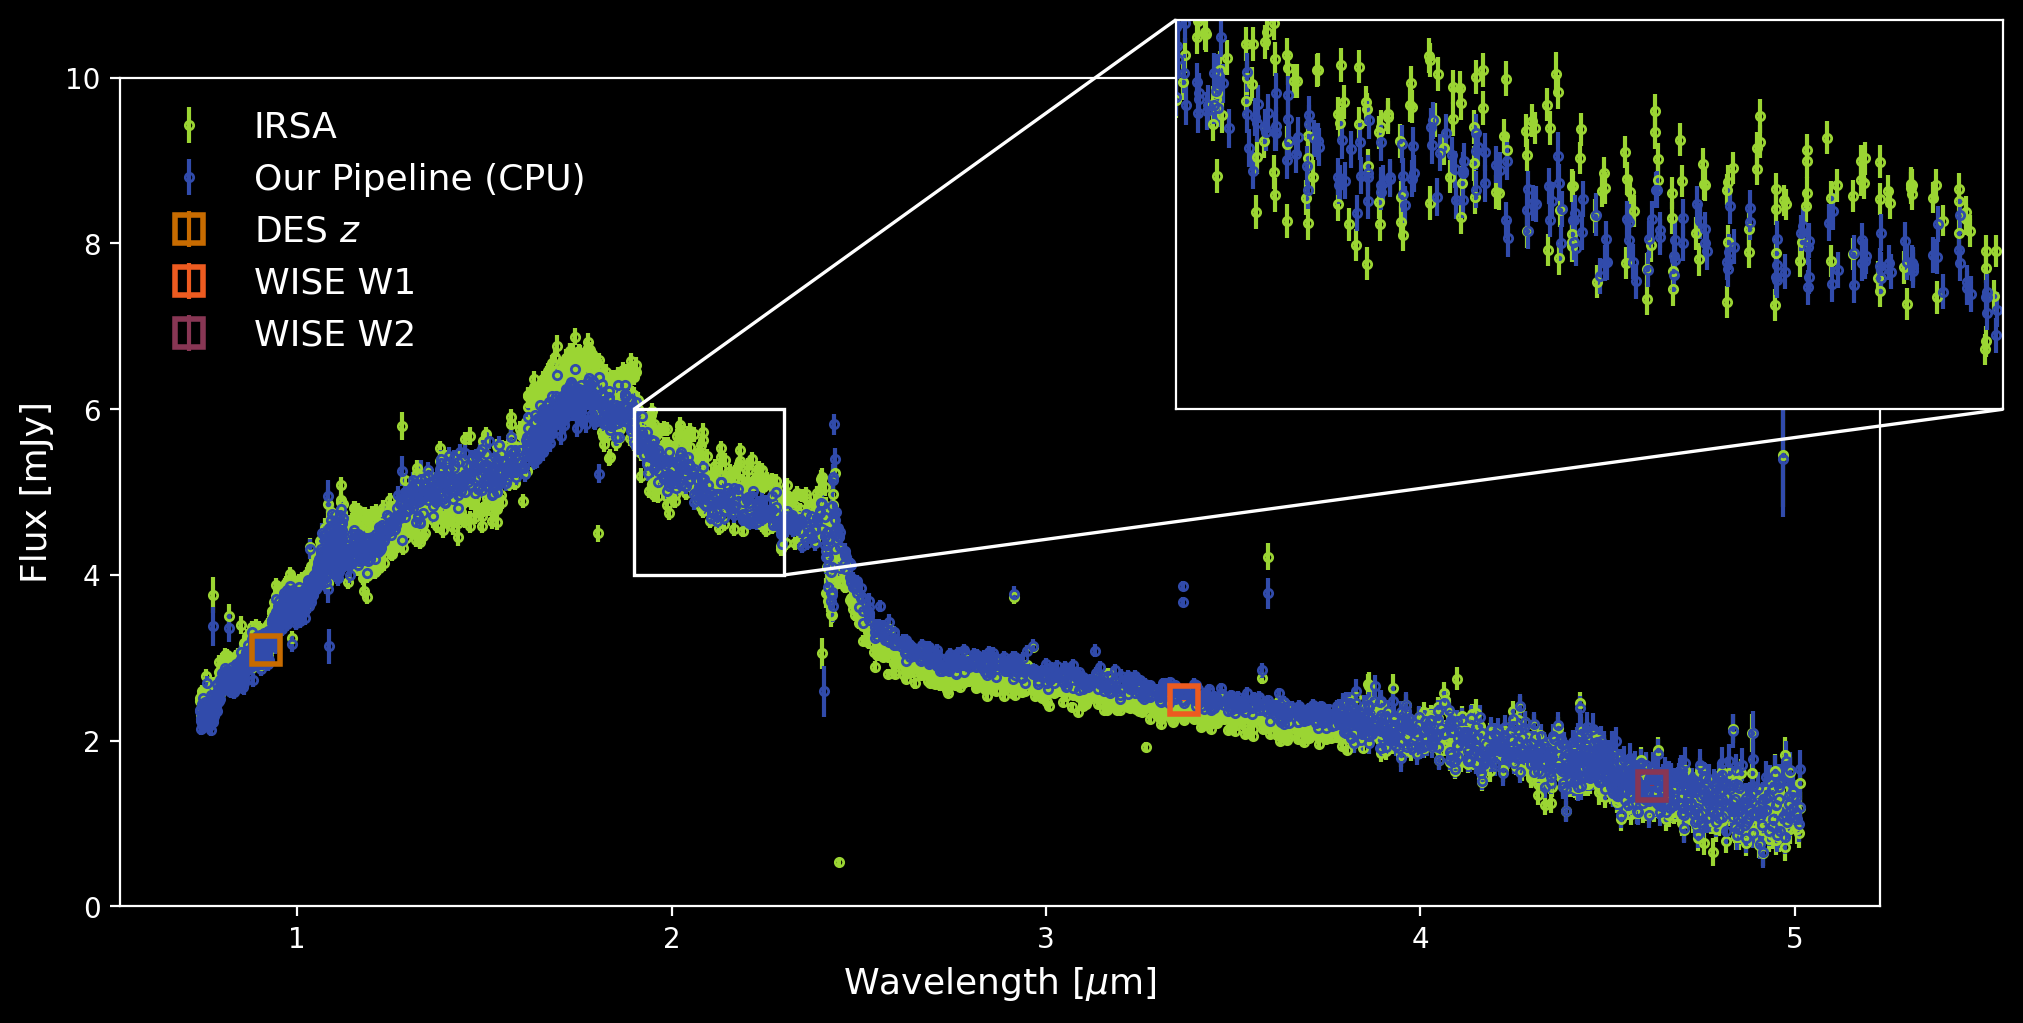

In [4]:
lambda_z, lambda_w1, lambda_w2 = 0.91585, 3.3682, 4.6179
# convert fluxes in nanomaggies to mJy
flux_z, flux_z_err = np.array([853.0325, 1/np.sqrt(2.779286)]) * 3.631e-3
flux_w1, flux_w1_err = np.array([684.88245, 1/np.sqrt(0.524595)]) * 3.631e-3
flux_w2, flux_w2_err = np.array([401.45563, 1/np.sqrt(0.328019)]) * 3.631e-3

# dark mode
plt.style.use("dark_background")

cpu_result = Table.read("/data1/hbahk/spherex-cluster/codes/realworld/specphot_results_testgal_a2255_cpu_nosersiccorr.parquet")
gpu_result_acc = Table.read("test_jax_optimizer_spherex.parquet")
gpu_result_bat = Table.read("test_jax_optimizer_spherex_batch_psfov5_f32_bucket.parquet")
gpu_result_bat = Table.read("test_jax_optimizer_spherex_batch.parquet")
gpu_result_bat_ = Table.read("test_jax_optimizer_spherex_batch_nosersiccorr.parquet")
irsa_result = Table.read("table_photometry.csv")
fig = plt.figure(figsize=(10, 5), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1)
ax.errorbar(irsa_result["lambda"], irsa_result["flux"]/1000, yerr=irsa_result["flux_err"]/1000, fmt=".", label="IRSA", color="#9bd533", mfc="none")
ax.errorbar(cpu_result["central_wavelength"], cpu_result["flux"], yerr=cpu_result["flux_err"], fmt=".", label="Our Pipeline (CPU)", color="#314bab", mfc="none")
# ax.errorbar(gpu_result_bat["central_wavelength"], gpu_result_bat["flux"], yerr=gpu_result_bat["flux_err"], fmt=".", label="Our Pipeline (GPU)", color="#ee2e43")
# ax.errorbar(gpu_result_bat["central_wavelength"], gpu_result_bat["flux"], yerr=gpu_result_bat["flux_err"], fmt=".", label="Our Pipeline (GPU-Linear)", color="#ee2e43")
# ax.errorbar(gpu_result_bat_["central_wavelength"], gpu_result_bat_["flux"], yerr=gpu_result_bat_["flux_err"], fmt=".", label="Our Pipeline (GPU-CG)", color="k", ms=1)
# ax.errorbar(gpu_result_bat_["central_wavelength"], gpu_result_bat_["flux"], yerr=gpu_result_bat_["flux_err"], fmt=".", label="Our Pipeline (GPU-CG)", color="#ee2e43")
ax.errorbar([lambda_z], [flux_z], yerr=[flux_z_err], fmt="s", label="DES $z$", ms=10, mfc="none", zorder=10, mew=2, color="#c76b00")
ax.errorbar([lambda_w1], [flux_w1], yerr=[flux_w1_err], fmt="s", label="WISE W1", ms=10, mfc="none", zorder=10, mew=2, color="#ed5b20")
ax.errorbar([lambda_w2], [flux_w2], yerr=[flux_w2_err], fmt="s", label="WISE W2", ms=10, mfc="none", zorder=10, mew=2, color="#883654")
ax.set_xlabel("Wavelength [$\mu$m]", fontsize=13)
ax.set_ylabel("Flux [mJy]", fontsize=13)
# ax.set_title("flux comparison")
# ax.set_xlim(0.4, 2.5)
ax.set_ylim(0, 10) 
#inset
axins = ax.inset_axes([0.6, 0.6, 0.47, 0.47])
axins.errorbar(irsa_result["lambda"], irsa_result["flux"]/1000, yerr=irsa_result["flux_err"]/1000, fmt=".", label="IRSA", color="#9bd533", mfc="none")
axins.errorbar(cpu_result["central_wavelength"], cpu_result["flux"], yerr=cpu_result["flux_err"], fmt=".", label="Our Pipeline (CPU)", color="#314bab", mfc="none")
# axins.errorbar(gpu_result_bat["central_wavelength"], gpu_result_bat["flux"], yerr=gpu_result_bat["flux_err"], fmt=".", label="Our Pipeline (GPU)", color="#ee2e43")
# axins.errorbar(gpu_result_bat_["central_wavelength"], gpu_result_bat_["flux"], yerr=gpu_result_bat_["flux_err"], fmt=".", label="Our Pipeline (GPU-CG)", color="#ee2e43")
axins.set_xlim(1.9, 2.3)
axins.set_ylim(4, 6)
axins.set_xticks([])
axins.set_yticks([])
ax.legend(loc="upper left", frameon=False, fontsize=13)
#connect the inset to the main plot
# ax.indicate_inset_zoom(axins, edgecolor="black")
pp, p1, p2 = mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="w", lw=1.2, zorder=10)
# pp, p1, p2 = mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="k", lw=1.2)

In [ ]:
lambda_z, lambda_w1, lambda_w2 = 0.91585, 3.3682, 4.6179
# convert fluxes in nanomaggies to mJy
flux_z, flux_z_err = np.array([853.0325, 1/np.sqrt(2.779286)]) * 3.631e-3
flux_w1, flux_w1_err = np.array([684.88245, 1/np.sqrt(0.524595)]) * 3.631e-3
flux_w2, flux_w2_err = np.array([401.45563, 1/np.sqrt(0.328019)]) * 3.631e-3



cpu_result = Table.read("/data1/hbahk/spherex-cluster/codes/realworld/specphot_results_testgal_a2255.parquet")
gpu_result_acc = Table.read("test_jax_optimizer_spherex.parquet")
gpu_result_bat = Table.read("test_jax_optimizer_spherex_batch_psfov5_f32_bucket.parquet")
gpu_result_bat = Table.read("test_jax_optimizer_spherex_batch.parquet")
gpu_result_bat_ = Table.read("test_jax_optimizer_spherex_batch_nosersiccorr.parquet")
irsa_result = Table.read("table_photometry.csv")
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
ax.errorbar(irsa_result["lambda"], irsa_result["flux"]/1000, yerr=irsa_result["flux_err"]/1000, fmt=".", label="IRSA", color="#9bd533", mfc="none")
ax.errorbar(cpu_result["central_wavelength"], cpu_result["flux"], yerr=cpu_result["flux_err"], fmt=".", label="Our Pipeline (CPU)", color="#314bab", mfc="none")
ax.errorbar(gpu_result_bat["central_wavelength"], gpu_result_bat["flux"], yerr=gpu_result_bat["flux_err"], fmt=".", label="Our Pipeline (GPU)", color="#ee2e43")
ax.errorbar(gpu_result_bat_["central_wavelength"], gpu_result_bat_["flux"], yerr=gpu_result_bat_["flux_err"], fmt=".", label="Our Pipeline (GPU)", color="k", alpha=0.3)
ax.errorbar([lambda_z], [flux_z], yerr=[flux_z_err], fmt="s", label="DES $z$", ms=10, mfc="none", zorder=10, mew=2, color="#c76b00")
ax.errorbar([lambda_w1], [flux_w1], yerr=[flux_w1_err], fmt="s", label="WISE W1", ms=10, mfc="none", zorder=10, mew=2, color="#ed5b20")
ax.errorbar([lambda_w2], [flux_w2], yerr=[flux_w2_err], fmt="s", label="WISE W2", ms=10, mfc="none", zorder=10, mew=2, color="#883654")
ax.set_xlabel("Wavelength [$\mu$m]", fontsize=13)
ax.set_ylabel("Flux [mJy]", fontsize=13)
# ax.set_title("flux comparison")
# ax.set_xlim(0.4, 2.5)
ax.set_ylim(0, 10) 
#inset
axins = ax.inset_axes([0.6, 0.6, 0.47, 0.47])
axins.errorbar(irsa_result["lambda"], irsa_result["flux"]/1000, yerr=irsa_result["flux_err"]/1000, fmt=".", label="IRSA", color="#9bd533", mfc="none")
axins.errorbar(cpu_result["central_wavelength"], cpu_result["flux"], yerr=cpu_result["flux_err"], fmt=".", label="Our Pipeline (CPU)", color="#314bab", mfc="none")
axins.errorbar(gpu_result_bat["central_wavelength"], gpu_result_bat["flux"], yerr=gpu_result_bat["flux_err"], fmt=".", label="Our Pipeline (GPU)", color="#ee2e43")
axins.set_xlim(1.9, 2.3)
axins.set_ylim(4, 6)
axins.set_xticks([])
axins.set_yticks([])
ax.legend(loc="upper left", frameon=False, fontsize=13)



In [35]:
np.argwhere((gpu_result_bat["flux"]<1.5)&(gpu_result_bat["central_wavelength"]>2.)&(gpu_result_bat["central_wavelength"]<3.5))

array([[1487],
       [1519],
       [1536],
       [1562],
       [1644],
       [1657],
       [1675],
       [1720]])

In [36]:
gpu_result_bat[(gpu_result_bat["flux"]<1.5)&(gpu_result_bat["central_wavelength"]>2.)&(gpu_result_bat["central_wavelength"]<3.5)]

cutout_index,observation_date,detector,x,y,central_wavelength,access_url,flux,flux_err
int32,float64,int32,float64,float64,float64,str200,float64,float64
1489,60898.3097489,4,1979.657568955129,1082.0866648133842,3.00211564975011,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W33_1B/l2b-v20-2025-265/4/level2_2025W33_1B_0059_3D4_spx_l2b-v20-2025-265.fits?center=258.2084186,64.0529535d&size=0.025625",0.7672634720802307,0.07725545018911362
1521,60913.9957625,4,949.1007224172091,1281.1609683418117,2.8312373005221545,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W35_1A/l2b-v20-2025-270/4/level2_2025W35_1A_0396_1D4_spx_l2b-v20-2025-270.fits?center=258.2084186,64.0529535d&size=0.025625",0.9718548655509949,0.08517394214868546
1538,60914.269235949,4,254.9530667901921,772.248200521055,3.218278863192649,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W35_1A/l2b-v20-2025-270/4/level2_2025W35_1A_0443_1D4_spx_l2b-v20-2025-270.fits?center=258.2084186,64.0529535d&size=0.025625",0.8111433386802673,0.0763581395149231
1564,60915.425591285,4,256.8457392555687,772.4583541292247,3.217996800048574,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W35_1A/l2b-v20-2025-270/4/level2_2025W35_1A_0657_2D4_spx_l2b-v20-2025-270.fits?center=258.2084186,64.0529535d&size=0.025625",0.6574329137802124,0.062147170305252075
1646,60920.248878287,4,888.5525794453144,1532.9762119404272,2.669850381279109,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W36_1A/l2b-v20-2025-271/4/level2_2025W36_1A_0288_1D4_spx_l2b-v20-2025-271.fits?center=258.2084186,64.0529535d&size=0.025625",0.7801982760429382,0.07860613614320755
1659,60920.587442407,4,201.32821725437861,1154.6766102454033,2.9447227547285544,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W36_1A/l2b-v20-2025-271/4/level2_2025W36_1A_0363_4D4_spx_l2b-v20-2025-271.fits?center=258.2084186,64.0529535d&size=0.025625",0.7065629959106445,0.07977461069822311
1677,60921.73756206,4,186.5235117223881,697.0884178120886,3.2799132282790064,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W36_1A/l2b-v20-2025-271/4/level2_2025W36_1A_0608_1D4_spx_l2b-v20-2025-271.fits?center=258.2084186,64.0529535d&size=0.025625",0.5960102677345276,0.06097423657774925
1722,60923.033674062,4,187.82235029706462,697.5775584484878,3.2794537453741954,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W36_2B/l2b-v20-2025-272/4/level2_2025W36_2B_0107_4D4_spx_l2b-v20-2025-272.fits?center=258.2084186,64.0529535d&size=0.025625",0.5994924902915955,0.061798565089702606


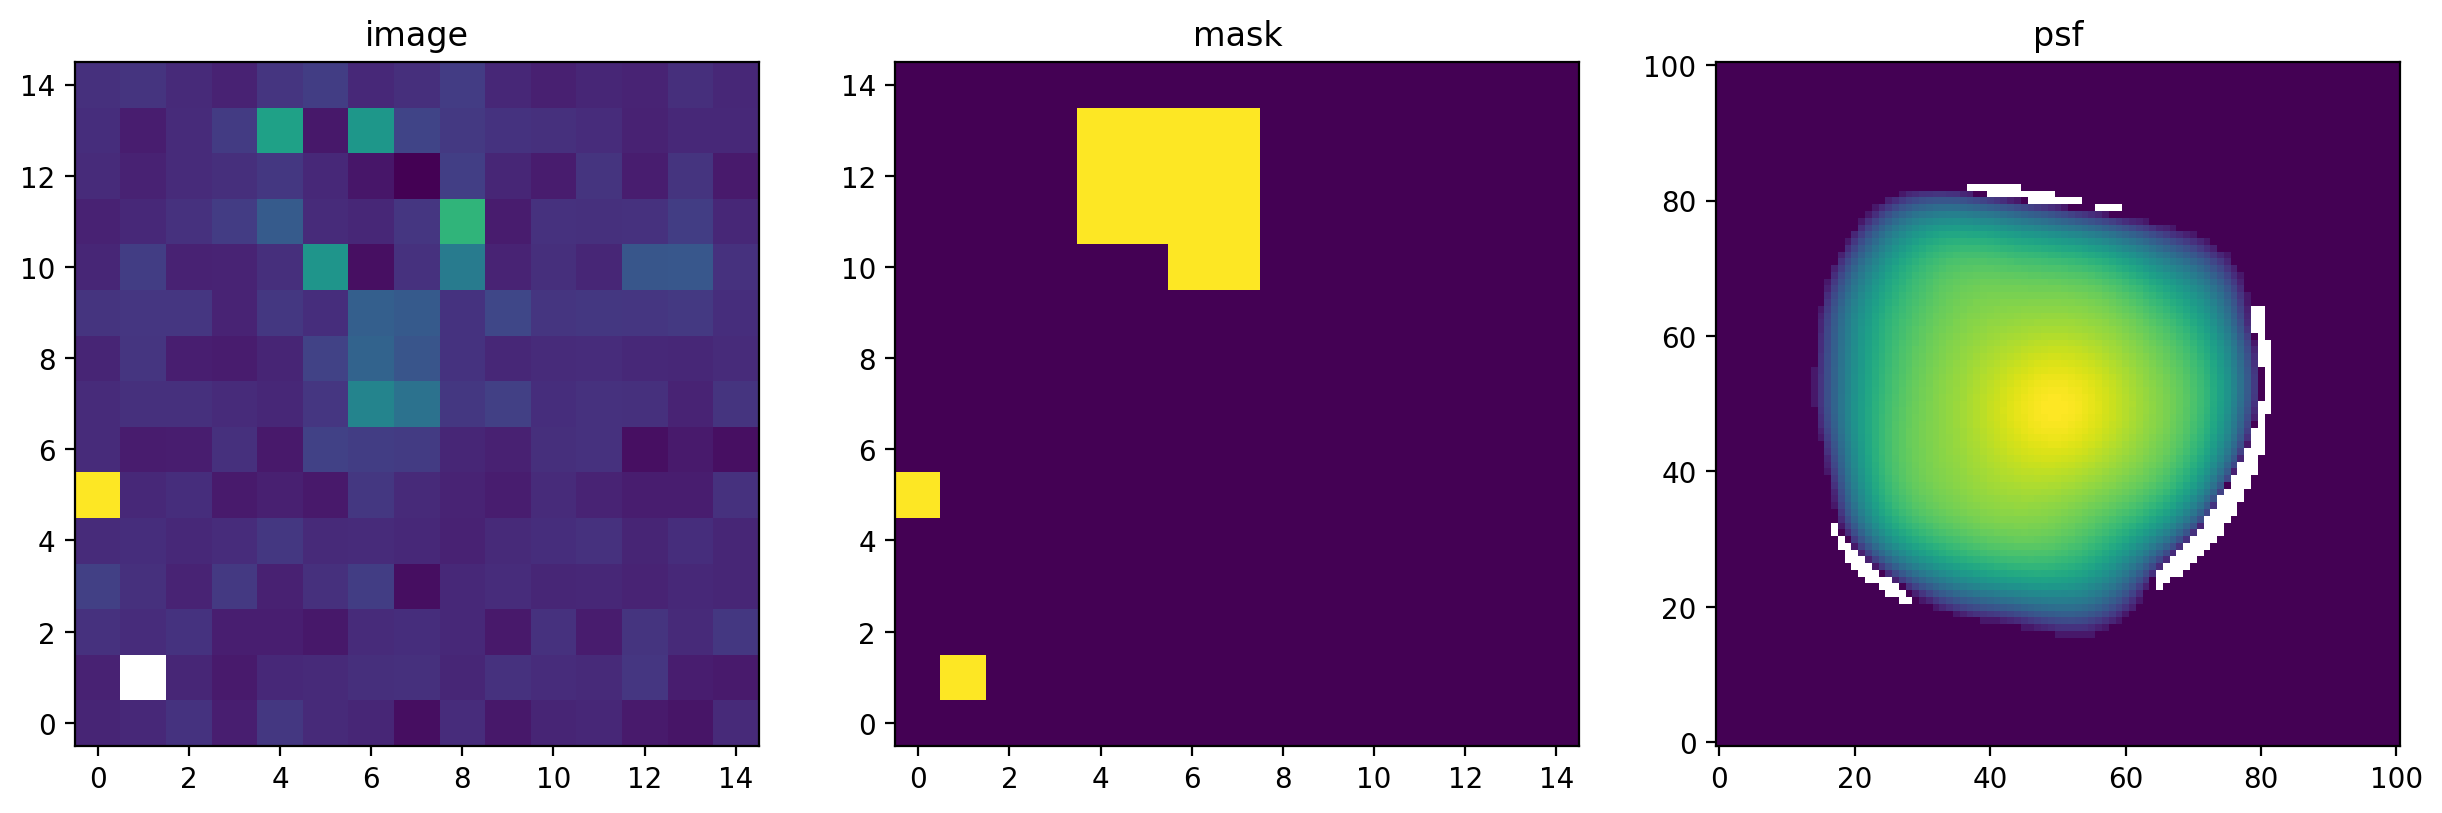

In [7]:
hdul = fits.open("testphot.fits")
hdr = hdul[1].header
wcs = WCS(hdr)

i = 127

img = hdul["IMAGE{}".format(i)].data
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(1, 3, 1)
ax.imshow(img, origin="lower")
ax.set_title("image")

flg = hdul["FLAGS{}".format(i)].data
mask = flg & MASKBITS != 0
ax = fig.add_subplot(1, 3, 2)
ax.imshow(mask, origin="lower")
ax.set_title("mask")

psf = hdul["PSF{}".format(i)].data
ax = fig.add_subplot(1, 3, 3)
ax.imshow(psf[0], origin="lower", norm="log")
ax.set_title("psf")
plt.show()



In [57]:
data.shape

(155, 155)

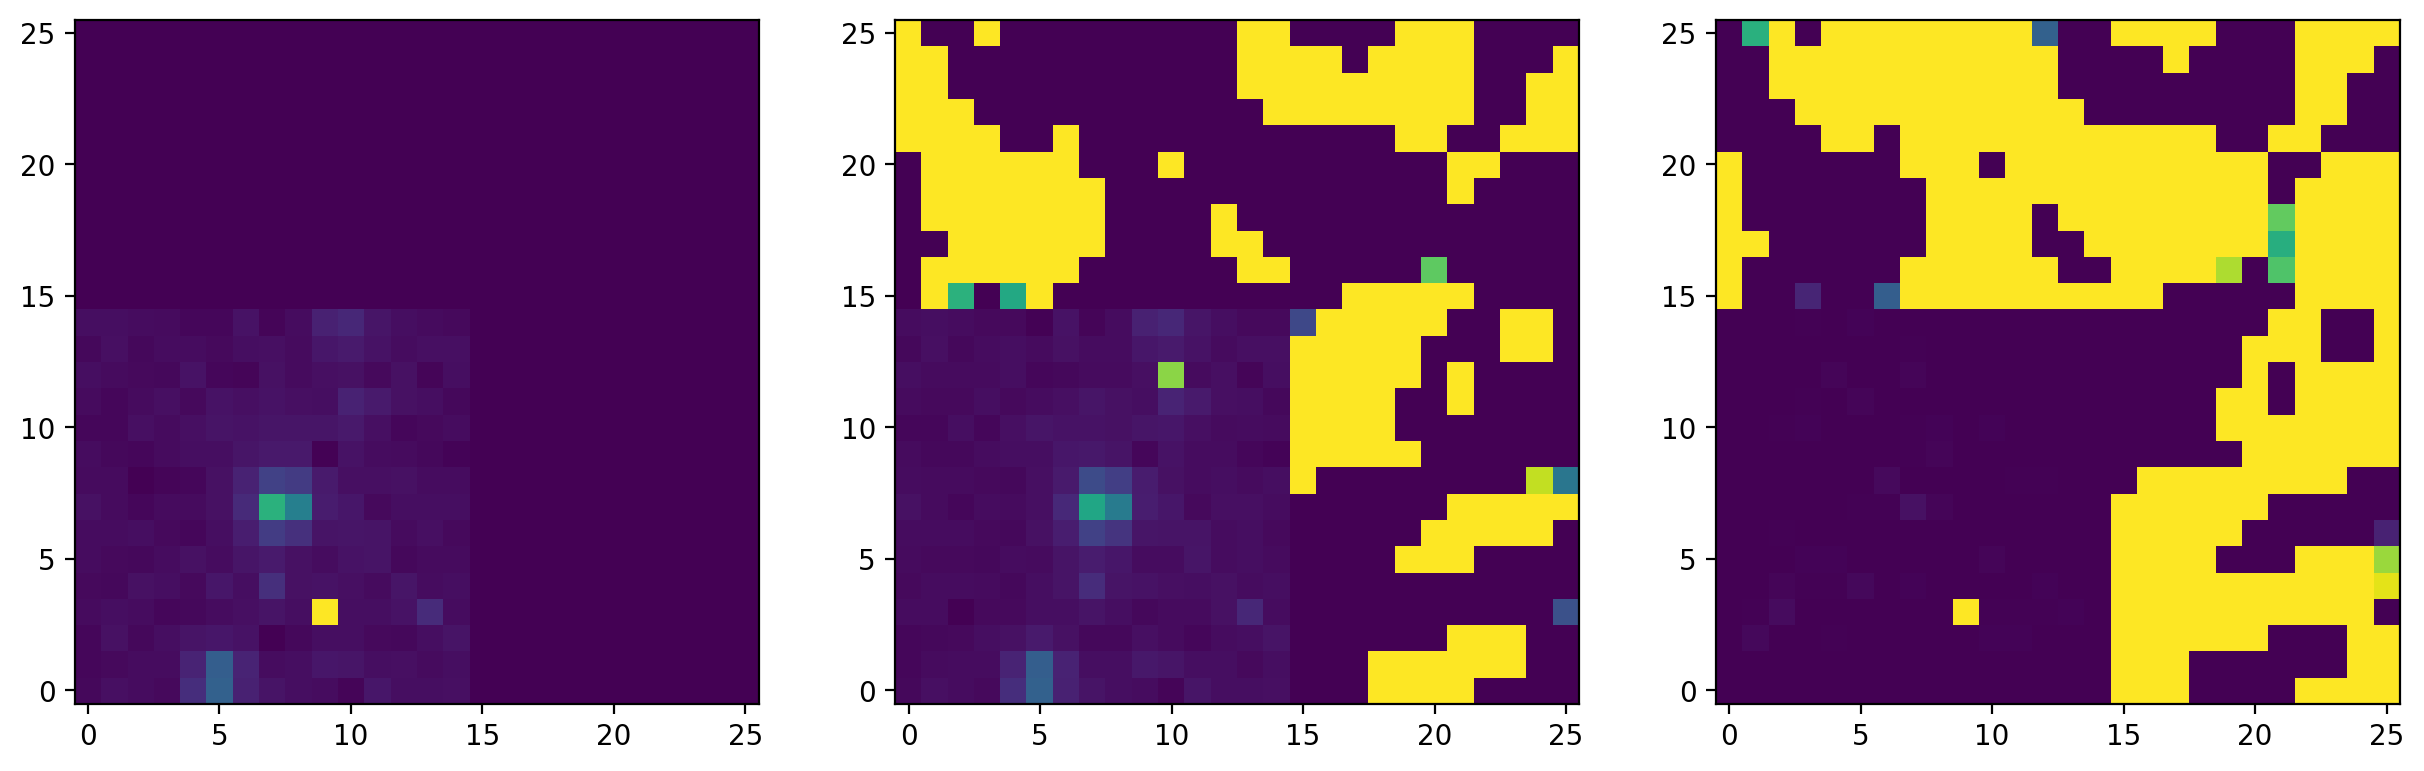

In [97]:
cutout_idx = 2924
data = np.load(f"outlier_cutout_plots/cutout_{cutout_idx:04d}_data.npy")
model = np.load(f"outlier_cutout_plots/cutout_{cutout_idx:04d}_model.npy")
resid = np.load(f"outlier_cutout_plots/cutout_{cutout_idx:04d}_resid.npy")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im = axes[0].imshow(data, origin="lower", vmin=0, vmax=1)
vmin, vmax = im.get_clim()
axes[1].imshow(model, origin="lower", vmin=vmin, vmax=vmax)
axes[2].imshow(resid, origin="lower", vmin=vmin, vmax=vmax)
# im = axes[1].imshow(model, origin="lower")
# vmin, vmax = im.get_clim()
# axes[0].imshow(data, origin="lower", vmin=vmin, vmax=vmax)
# axes[2].imshow(resid, origin="lower", vmin=vmin, vmax=vmax)
plt.show()



In [65]:
cutout_index = 1
idx = cutout_index - 1
img_idx = 2 + idx * 6
flg_idx = img_idx + 1

with fits.open("testphot.fits") as hdul:
    flg = hdul[flg_idx].data
    y, x = 12, 4
    print("flag value:", flg[y, x])
    print("masked:", (flg[y, x] & MASKBITS) != 0)

flag value: 131142
masked: True


In [ ]:
from astropy.wcs import WCS
wcs = WCS(hdul["IMAGE{}".format(i)].header)
wcs.celestial.proj_plane_pixel_area().to(u.sr)


<Quantity 8.91472933e-10 sr>

In [54]:
gpu_result_bat[gpu_result_bat["central_wavelength"]>2.4]

cutout_index,observation_date,detector,x,y,central_wavelength,access_url,flux,flux_err
int32,float64,int32,float64,float64,float64,str200,float64,float64
1,60790.082397558,6,1854.5150766535291,1603.9896855318884,4.52867291985293,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/6/level2_2025W17_4B_0051_1D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625",nan,nan
3,60790.083889803,6,1855.8010034318509,1489.5503256805505,4.5614530635549855,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/6/level2_2025W17_4B_0051_2D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625",nan,nan
6,60790.08538206,6,1856.5425213583871,1375.0709504143954,4.59483859223839,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/6/level2_2025W17_4B_0051_3D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625",nan,nan
7,60790.086874317,6,1856.8946624172227,1260.6157762242412,4.628289559232978,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/6/level2_2025W17_4B_0051_4D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625",nan,nan
9,60790.350257037,6,1956.0201494675161,234.47878406359072,4.941259134426147,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/6/level2_2025W17_4B_0091_1D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625",nan,nan
11,60790.351749282,6,1957.0928640604131,119.46895827499543,4.977319301321879,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/6/level2_2025W17_4B_0091_2D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625",nan,nan
13,60790.353241528,3,1960.8728846844176,16.825270118945234,2.4296425402562636,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/3/level2_2025W17_4B_0091_3D3_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625",nan,nan
14,60790.353241539,6,1957.6370401528395,4.5708435781344665,5.013327845695745,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/6/level2_2025W17_4B_0091_3D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625",nan,nan
16,60790.895622326,6,1891.2045529993413,1580.3483976468099,4.536448379333558,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/6/level2_2025W17_4B_0175_1D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625",nan,nan


In [30]:
gpu_result_bat[gpu_result_bat["flux"]<0.6]

cutout_index,observation_date,detector,x,y,central_wavelength,access_url,flux,flux_err
int32,float64,int32,float64,float64,float64,str200,float64,float64
97,60794.500479653,6,1928.5182138077357,1089.374863333556,4.681348215624522,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W18_1B/l2b-v20-2025-240/6/level2_2025W18_1B_0146_3D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625",0.07201882322845025,0.17336770937069462
127,60796.404133032,6,1931.5489886839978,1889.2739901532836,4.4512370662164615,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W18_1B/l2b-v20-2025-240/6/level2_2025W18_1B_0439_4D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625",0.3239721970986009,0.17346999005627
162,60798.168029826,6,1947.6435789636553,488.6808723302485,4.861596492763641,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W18_2B/l2b-v20-2025-241/6/level2_2025W18_2B_0254_2D6_spx_l2b-v20-2025-241.fits?center=258.2084186,64.0529535d&size=0.025625",0.4367316124324779,0.18034701164753847
174,60798.504959329,3,1960.0736327312554,590.8872305171968,2.1813577869644094,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W18_2B/l2b-v20-2025-241/3/level2_2025W18_2B_0304_2D3_spx_l2b-v20-2025-241.fits?center=258.2084186,64.0529535d&size=0.025625",0.5910759091108001,0.08927295624649931
276,60804.01084088,3,1960.7706938017473,587.5293952085444,2.1828617619975144,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W19_2B/l2b-v20-2025-247/3/level2_2025W19_2B_0079_3D3_spx_l2b-v20-2025-247.fits?center=258.2084186,64.0529535d&size=0.025625",0.4402449758396707,0.09021169714827564
402,60809.925778241,6,1941.368038825778,747.7435326665359,4.783167257002132,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W20_1C/l2b-v20-2025-247/6/level2_2025W20_1C_0458_4D6_spx_l2b-v20-2025-247.fits?center=258.2084186,64.0529535d&size=0.025625",0.31111694163202297,0.18559392736096794
439,60810.532681285,6,1613.7269578553487,1295.9811100993466,4.612324388378759,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W20_2D/l2b-v20-2025-247/6/level2_2025W20_2D_0007_4D6_spx_l2b-v20-2025-247.fits?center=258.2084186,64.0529535d&size=0.025625",0.10288156638842111,0.1465958293391077
468,60812.231469676,6,1913.8555914492417,1062.024622453325,4.689051601765202,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W20_2D/l2b-v20-2025-247/6/level2_2025W20_2D_0288_4D6_spx_l2b-v20-2025-247.fits?center=258.2084186,64.0529535d&size=0.025625",0.35967611785800746,0.17715200200744163
626,60820.312306215,6,1816.9409275070907,1117.757218407494,4.669644496707707,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W21_2C/l2b-v20-2025-250/6/level2_2025W21_2C_0465_1D6_spx_l2b-v20-2025-250.fits?center=258.2084186,64.0529535d&size=0.025625",0.04944300799141705,0.1559169102397


In [2]:
import site, glob, os
paths=[]
for sp in site.getsitepackages():
    paths += glob.glob(os.path.join(sp, "nvidia", "*", "lib"))
print(":".join(paths))

print(os.environ["LD_LIBRARY_PATH"])
os.environ["LD_LIBRARY_PATH"] = ":".join(paths)

/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/nvjitlink/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/nccl/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/cuda_runtime/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/cuda_nvrtc/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/cuda_cupti/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/cuda_cccl/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/cublas/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/nvshmem/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/cusparse/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/cufft/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/cudnn/lib:/home/hbahk/miniconda3/e

In [3]:
import jax
jax.config.update("jax_enable_x64", True)
print(jax.devices())
print(jax.default_backend())

[CudaDevice(id=0), CudaDevice(id=1)]
gpu


In [4]:
cutout_size = 6.15 * 15 * u.arcsec
gra, gdec = 258.2084186 * u.deg, 64.0529535 * u.deg

gco = SkyCoord(ra=gra, dec=gdec)

output_filename = "testphot.fits"

In [18]:
# Define the service endpoint for IRSA's Table Access Protocol (TAP)
# so that we can query SPHEREx metadata tables.
service = pyvo.dal.TAPService("https://irsa.ipac.caltech.edu/TAP")

# Define a query that will search the appropriate SPHEREx metadata tables
# for spectral images that cover the chosen coordinates and match the
# specified bandpass. Return the cutout data access URL and the time of observation.
# Sort by observation time.
query = f"""
SELECT
    'https://irsa.ipac.caltech.edu/' || a.uri || '?center={gra.to(u.degree).value},{gdec.to(u.degree).value}d&size={cutout_size.to(u.degree).value}' AS uri,
    p.time_bounds_lower
FROM spherex.artifact a
JOIN spherex.plane p ON a.planeid = p.planeid
WHERE 1 = CONTAINS(POINT('ICRS', {gra.to(u.degree).value}, {gdec.to(u.degree).value}), p.poly)
ORDER BY p.time_bounds_lower
"""

# Execute the query and return as an astropy Table.
t1 = time.time()
results = service.search(query)
print("Time to do TAP query: {:2.2f} seconds.".format(time.time() - t1))
print("Number of images found: {}".format(len(results)))

Time to do TAP query: 6.53 seconds.
Number of images found: 3219


In [5]:
XX, YY = np.meshgrid(np.arange(11), np.arange(11))
ZXGRID = XX.flatten() + 1
ZYGRID = YY.flatten() + 1


def get_psf_zone_table(psf_header):
    """
    Extract the PSF zone table from the PSF extension header.
    """
    xctr = {}
    yctr = {}

    for key, val in psf_header.items():
        # Look for keys like XCTR* or YCTR*
        xm = re.match(r"(XCTR*)", key)
        if xm:
            xplane = int(key.split("_")[1])
            xctr[xplane] = val
        ym = re.match(r"(YCTR*)", key)
        if ym:
            yplane = int(key.split("_")[1])
            yctr[yplane] = val

    assert len(xctr) == len(yctr)

    tab = Table(names=["zone_id", "x", "y"], dtype=[int, float, float])
    for zone_id in xctr.keys():
        tab.add_row([zone_id, xctr[zone_id], yctr[zone_id]])

    return tab


def get_nearest_psf_zone_index(x, y, psf_zone_table):
    dist = np.sqrt((psf_zone_table["x"] - x) ** 2 + (psf_zone_table["y"] - y) ** 2)
    return psf_zone_table["zone_id"][np.argmin(dist)]


from astropy.utils.data import conf

def process_cutout(row, ra, dec, cache, timeout=3600):
    """
    Downloads the cutouts given in a row of the table including all SPHEREx images overlapping with a position.

    Parameters:
    ===========

    row : astropy.table row
        Row of a table that will be changed in place by this function. The table
        is created by the SQL TAP query.
    ra,dec : coordinates (astropy units)
        Ra and Dec coordinates (same as used for the TAP query) with attached astropy units
    cache : bool
        If set to `True`, the output of cached and the cutout processing will run faster next time.
        Turn this feature off by setting `cache = False`.
    timeout : float
        Timeout for the remote request in seconds.
    """
    with conf.set_temp('remote_timeout', timeout):
        with fits.open(row["uri"], cache=cache) as hdulist:
            # There are seven HDUs:
            # 0 contains minimal metadata in the header and no data.
            # 1 through 6 are: IMAGE, FLAGS, VARIANCE, ZODI, PSF, WCS-WAVE
            header = hdulist[1].header

            # Compute pixel coordinates corresponding to cutout position.
            spatial_wcs = WCS(header)
            x, y = spatial_wcs.world_to_pixel(
                SkyCoord(ra=ra, dec=dec, unit="deg", frame="icrs")
            )

            # Compute the original pixel positions
            crpix1a = header["CRPIX1A"]
            crpix2a = header["CRPIX2A"]
            x_orig = 1 + (x - crpix1a)
            y_orig = 1 + (y - crpix2a)
            row["X"] = x_orig
            row["Y"] = y_orig

            # save the detector array number
            row["DETECTOR"] = hdulist[1].header["DETECTOR"]

            # Compute wavelength at cutout position.
            spectral_wcs = WCS(header, fobj=hdulist, key="W")
            spectral_wcs.sip = None
            wavelength, bandpass = spectral_wcs.pixel_to_world(x, y)
            row["central_wavelength"] = wavelength.to(u.micrometer).value

            # Collect the HDUs for this cutout and append the row's cutout_index to the EXTNAME.
            hdus = []
            for hdu in hdulist[
                1:5
            ]:  # skip the primary header and append until the ZODI extension
                hdu.header["EXTNAME"] = f"{hdu.header['EXTNAME']}{row['cutout_index']}"
                hdus.append(
                    hdu.copy()
                )  # Copy so the data is available after the file is closed

            # get the PSF cube only for the PSF zones that overlap with the cutout
            psf_zone_table = get_psf_zone_table(hdulist[5].header)
            xlo, xhi = 0, hdulist[1].header["NAXIS1"]
            ylo, yhi = 0, hdulist[1].header["NAXIS2"]
            xlo_orig, xhi_orig = 1 + (xlo - crpix1a), 1 + (xhi - crpix1a)
            ylo_orig, yhi_orig = 1 + (ylo - crpix2a), 1 + (yhi - crpix2a)

            # get the PSF zone coords for the lower left and upper right corners of the cutout
            zid_ll = get_nearest_psf_zone_index(xlo_orig, ylo_orig, psf_zone_table)
            zid_ur = get_nearest_psf_zone_index(xhi_orig, yhi_orig, psf_zone_table)
            zx_ll, zy_ll = ZXGRID[zid_ll - 1], ZYGRID[zid_ll - 1]
            zx_ur, zy_ur = ZXGRID[zid_ur - 1], ZYGRID[zid_ur - 1]

            # get the zone indices for the overlapping zones
            sel = (
                (ZXGRID >= zx_ll)
                & (ZXGRID <= zx_ur)
                & (ZYGRID >= zy_ll)
                & (ZYGRID <= zy_ur)
            )

            # get the PSF cube for the overlapping zones
            psf_cube = hdulist[5].data[sel, :, :]

            # replace the PSF extension with the new PSF cube and append the new PSF extension
            hdulist[5].data = psf_cube
            hdulist[5].header["NAXIS3"] = psf_cube.shape[0]

            hdulist[5].header["EXTNAME"] = f"PSF{row['cutout_index']}"
            hdus.append(hdulist[5].copy())

            # save lookup table for the PSF zone indices
            cols = fits.ColDefs(
                [
                    fits.Column(
                        name="zone_id",
                        format="J",
                        array=psf_zone_table["zone_id"][sel],
                        unit="",
                    ),
                    fits.Column(
                        name="x", format="D", array=psf_zone_table["x"][sel], unit=""
                    ),
                    fits.Column(
                        name="y", format="D", array=psf_zone_table["y"][sel], unit=""
                    ),
                ]
            )
            psf_zone_table_hdu = fits.BinTableHDU.from_columns(cols)
            psf_zone_table_hdu.header["EXTNAME"] = f"PSF_ZONE_LOOKUP{row['cutout_index']}"
            hdus.append(psf_zone_table_hdu)

            row["hdus"] = hdus

In [ ]:
results_table_serial = results.to_table()
results_table_serial["time_bounds_lower"] = results_table_serial["time_bounds_lower"] * 100
results_table_serial["cutout_index"] = range(1, len(results_table_serial) + 1)
results_table_serial["central_wavelength"] = np.full(len(results_table_serial), np.nan)
results_table_serial["X"] = np.full(len(results_table_serial), np.nan)
results_table_serial["Y"] = np.full(len(results_table_serial), np.nan)
results_table_serial["DETECTOR"] = np.full(len(results_table_serial), np.nan)
results_table_serial["hdus"] = np.full(len(results_table_serial), None)

t1 = time.time()
for row in results_table_serial:
    process_cutout(
        row, gra, gdec, cache=True
    )  # some results give "Arrays do not overlap" error
print(
    "Time to create cutouts in serial mode: {:2.2f} minutes.".format(
        (time.time() - t1) / 60
    )
)

In [38]:
results_table_parallel = results.to_table()
results_table_parallel["cutout_index"] = range(1, len(results_table_parallel) + 1)
results_table_parallel["central_wavelength"] = np.full(
    len(results_table_parallel), np.nan
)
results_table_parallel["X"] = np.full(len(results_table_parallel), np.nan)
results_table_parallel["Y"] = np.full(len(results_table_parallel), np.nan)
results_table_parallel["DETECTOR"] = np.full(len(results_table_parallel), np.nan)
results_table_parallel["hdus"] = np.full(len(results_table_parallel), None)

t1 = time.time()
with concurrent.futures.ThreadPoolExecutor(max_workers=50) as executor:
    futures = [
        executor.submit(process_cutout, row, gra, gdec, True)
        for row in results_table_parallel
    ]
    concurrent.futures.wait(futures)
print(
    "Time to create cutouts in parallel mode: {:2.2f} minutes.".format(
        (time.time() - t1) / 60
    )
)

Time to create cutouts in parallel mode: 5.94 minutes.


In [39]:
results_table_parallel_copy = results_table_parallel.copy()

excluded_index = []
for i in range(len(results_table_parallel["hdus"])):
    fits_hdulist = results_table_parallel["hdus"][i]
    cutout_index = results_table_parallel["cutout_index"][i]
    if fits_hdulist is None:
        print(f"No cutout found for cutout index {cutout_index}")
        excluded_index.append(i)

results_table_parallel.remove_rows(excluded_index)

# Create a summary table HDU with renamed columns
cols = fits.ColDefs(
    [
        fits.Column(
            name="cutout_index",
            format="J",
            array=results_table_parallel["cutout_index"],
            unit="",
        ),
        fits.Column(
            name="observation_date",
            format="D",
            array=results_table_parallel["time_bounds_lower"],
            unit="d",
        ),
        fits.Column(
            name="detector",
            format="J",
            array=results_table_parallel["DETECTOR"],
            unit="",
        ),
        fits.Column(name="x", format="D", array=results_table_parallel["X"], unit=""),
        fits.Column(name="y", format="D", array=results_table_parallel["Y"], unit=""),
        fits.Column(
            name="central_wavelength",
            format="D",
            array=results_table_parallel["central_wavelength"],
            unit="um",
        ),
        fits.Column(
            name="access_url",
            format="A200",
            array=results_table_parallel["uri"],
            unit="",
        ),
    ]
)
table_hdu = fits.BinTableHDU.from_columns(cols)
table_hdu.header["EXTNAME"] = "CUTOUT_INFO"

No cutout found for cutout index 1318


In [40]:
primary_hdu = fits.PrimaryHDU()
hdulist_list = [primary_hdu, table_hdu]
for i in range(len(results_table_parallel["hdus"])):
    fits_hdulist = results_table_parallel["hdus"][i]
    cutout_index = results_table_parallel["cutout_index"][i]
    if fits_hdulist is not None:
        hdulist_list.extend(fits_hdulist)
    else:
        print(f"No cutout found for cutout index {cutout_index}")
        print("This should not happen after running the cell above")
combined_hdulist = fits.HDUList(hdulist_list)

In [42]:
# Write the final MEF
combined_hdulist.writeto(output_filename, overwrite=True)

In [43]:
summary_table = Table.read(output_filename, hdu=1)
summary_table

cutout_index,observation_date,detector,x,y,central_wavelength,access_url
,d,,,,um,
int32,float64,int32,float64,float64,float64,bytes200
1,60790.082397558,6,1854.5150766535291,1603.9896855318884,4.52867291985293,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/6/level2_2025W17_4B_0051_1D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625"
2,60790.082397569,3,1854.9196650672843,1617.5910652894993,1.774208824638501,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/3/level2_2025W17_4B_0051_1D3_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625"
3,60790.083889803,6,1855.8010034318509,1489.5503256805505,4.5614530635549855,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/6/level2_2025W17_4B_0051_2D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625"
4,60790.083889803,3,1856.3570307219702,1503.0051836671403,1.815464382083945,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/3/level2_2025W17_4B_0051_2D3_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625"
5,60790.08538206,3,1857.3063025893746,1388.4542344115848,1.8579037672693253,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/3/level2_2025W17_4B_0051_3D3_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625"
6,60790.08538206,6,1856.5425213583871,1375.0709504143954,4.59483859223839,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/6/level2_2025W17_4B_0051_3D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625"
7,60790.086874317,6,1856.8946624172227,1260.6157762242412,4.628289559232978,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/6/level2_2025W17_4B_0051_4D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625"
8,60790.086874317,3,1857.8600880347394,1273.8694210026813,1.900923794377697,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/3/level2_2025W17_4B_0051_4D3_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625"


In [44]:
nbr_images = np.nanmin([10, len(summary_table)])
imgs = []
wcss = []
with fits.open(output_filename) as hdul:
    for ii in range(nbr_images):
        extname = "IMAGE{}".format(summary_table["cutout_index"][ii])
        imgs.append(hdul[extname].data)
        wcss.append(WCS(hdul[extname].header))

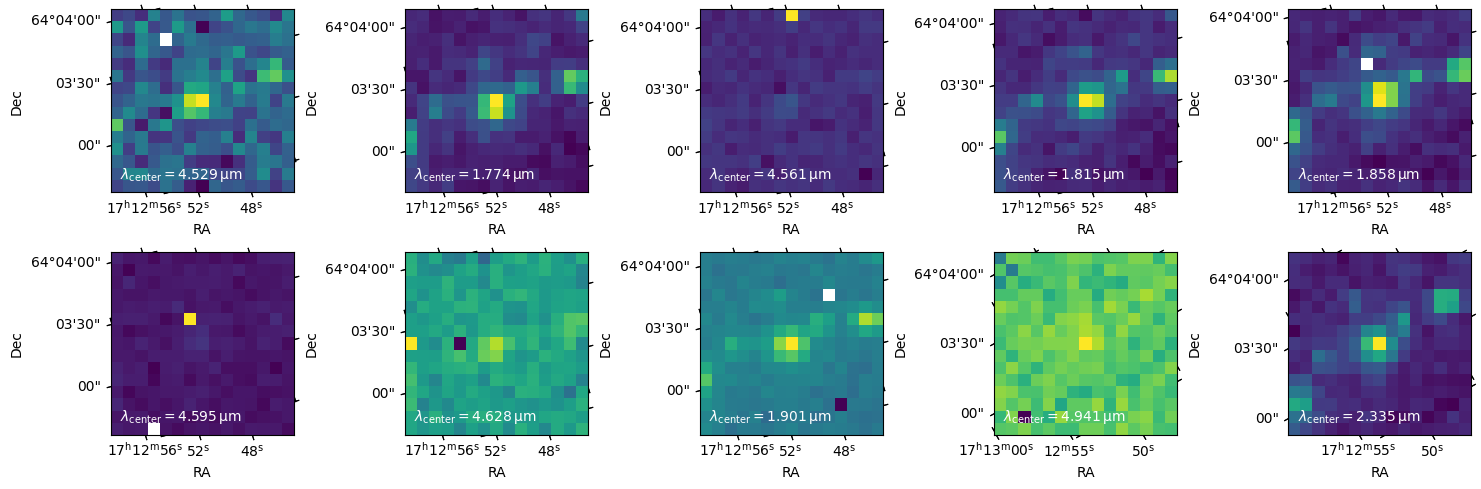

In [45]:
fig = plt.figure(figsize=(15, 5))
# axs = [fig.add_subplot(2, 5, ii + 1) for ii in range(10)]

for ii, img in enumerate(imgs):
    ax = fig.add_subplot(2, 5, ii + 1, projection=wcss[ii].celestial)
    ax.imshow(imgs[ii], norm="log", origin="lower")
    ax.text(
        0.05,
        0.05,
        r"$\lambda_{\rm center} = %2.4g \,{\rm \mu m}$"
        % summary_table["central_wavelength"][ii],
        va="bottom",
        ha="left",
        color="white",
        transform=ax.transAxes,
    )
    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")

fig.tight_layout()

In [46]:
from getpass import getpass
from dl import authClient as ac, queryClient as qc, storeClient as sc
from dl.helpers.utils import convert

# get token
token = ac.login(input("Enter user name: "), getpass("Enter password: "))
print(f"Login on the data-lab - username: {ac.whoAmI()}")

schema = qc.schema("ls_dr10.tractor")
# print(schema)

Login on the data-lab - username: bahkhyeonguk


In [47]:
colnames_of_interest_ls = [
    "ls_id",
    "type",
    "ra",
    "dec",
    "flux_g",
    "flux_ivar_g",
    "flux_ivar_g",
    "flux_r",
    "flux_ivar_r",
    "flux_i",
    "flux_ivar_i",
    "flux_z",
    "flux_ivar_z",
    "flux_w1",
    "flux_ivar_w1",
    "flux_w2",
    "flux_ivar_w2",
    "mag_g",
    "mag_r",
    "mag_i",
    "mag_z",
    "sersic",
    "shape_r",
    "shape_e1",
    "shape_e2",
    "dered_flux_g",
    "dered_flux_r",
    "dered_flux_i",
    "dered_flux_z",
    "dered_flux_w1",
    "dered_flux_w2",
    "g_r",
    "r_z",
    "z_w1",
]


def async_query_ls_catalog(
    cname, cra, cdec, rlim, colnames="*", query_again=False, logger=None
):
    if colnames == "*":
        colnames_str = "*"
    else:
        colnames_str = ", ".join(colnames)

    out = f"vos://tmp/ls_{cname}.csv"

    query = f"SELECT {colnames_str} FROM ls_dr10.tractor WHERE q3c_radial_query(ra, dec, {cra}, {cdec}, {rlim})"
    if logger:
        logger.info(f"{cname} - Generated SQL query: {query}")

    try:
        jobid = qc.query(sql=query, out=out, async_=True)
        if logger:
            logger.info(f"{cname} - Query submitted. Job ID: {jobid}")
    except Exception as e:
        if logger:
            logger.error(f"An error occurred: {e} - returning None for jobid.")
        return None

    return jobid


def get_async_query_result(jobid, logger=None):
    status = qc.status(jobid)
    if status == "COMPLETED":

        res = qc.results(jobid)
        tab = convert(res, "table")
        for col in tab.colnames:
            if tab[col].dtype == "float64":
                tab[col] = tab[col].astype("float32")
        if logger:
            logger.info(f"Results retrieved for job ID: {jobid}")
        return tab
    else:
        if logger:
            logger.warning(
                f"Query for job ID: {jobid} not completed. Status: {status} - returning None."
            )
        return None

In [6]:
# query async for all clusters
name = "testgal"
rlim = cutout_size.to(u.deg).value
jobid = async_query_ls_catalog(
    name, gra.value, gdec.value, rlim, colnames_of_interest_ls
)
if jobid is not None:
    print(f"Submitted job ID: {jobid} for target: {name}")
else:
    print(f"Query for {name} failed - job ID is None.")

Submitted job ID: vyapvnbdehwcaq9t for target: testgal


In [7]:
# check status
status = qc.status(jobid)
print(f"Job ID: {jobid} for target: {name} - Status: {status}")

Job ID: vyapvnbdehwcaq9t for target: testgal - Status: COMPLETED


In [8]:
# get results
tab = get_async_query_result(jobid)
tab = tab[tab["type"] != "DUP"]
tab.write(f"ls_{name}.parquet", overwrite=True)
tab


Total time: 0.81s for 52.12 KB


ls_id,type,ra,dec,flux_g,flux_ivar_g,flux_r,flux_ivar_r,flux_i,flux_ivar_i,flux_z,flux_ivar_z,flux_w1,flux_ivar_w1,flux_w2,flux_ivar_w2,mag_g,mag_r,mag_i,mag_z,sersic,shape_r,shape_e1,shape_e2,dered_flux_g,dered_flux_r,dered_flux_i,dered_flux_z,dered_flux_w1,dered_flux_w2,g_r,r_z,z_w1
int64,str3,float32,float32,float32,float32,float32,float32,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,float32
9907740467660295,DEV,258.2582,64.041595,2.792252,99.57568,11.14222,33.81126,-9999,-9999,32.067883,5.52395,46.528812,2.514053,28.829798,1.153185,21.385113,19.88257,-9999,18.734825,4.0,2.068004,0.038371,0.071868,3.032423,11.779064,-9999,33.080536,46.749126,28.913555,1.502542,1.147745,0.404131
9907740467660249,PSF,258.25333,64.04283,15.399517,216.5679,22.51637,98.35317,-9999,-9999,26.744759,38.676476,0.393021,5.699852,-0.335298,2.336979,19.531233,19.118753,-9999,18.931904,0.0,0.0,0.0,0.0,16.719563,23.798986,-9999,27.58651,0.394876,-0.336269,0.412479,0.18685,-4.582056
9907740467660084,REX,258.2386,64.031944,0.354643,187.94604,0.780392,66.958336,-9999,-9999,1.065918,9.389067,-2.429119,6.870693,-2.849295,2.400165,23.625523,22.769218,-9999,22.43069,1.0,1.212734,0.0,0.0,0.384558,0.824146,-9999,1.098944,-2.440407,-2.857419,0.856304,0.338528,nan
9907740467660056,PSF,258.2358,64.03088,3.200817,441.37634,5.774232,182.27025,-9999,-9999,7.109165,51.10537,0.998748,5.890336,0.104008,2.255422,21.236849,20.596264,-9999,20.370453,0.0,0.0,0.0,0.0,3.470095,6.097124,-9999,7.328863,1.003378,0.104303,0.640585,0.225811,-2.130907
9907740467660242,REX,258.25287,64.03704,0.383272,481.53137,0.957861,182.80154,-9999,-9999,1.744912,39.851593,2.920644,3.946035,3.61186,1.712913,23.541233,22.546743,-9999,21.895567,1.0,0.28447,0.0,0.0,0.416038,1.012281,-9999,1.799688,2.934393,3.622293,0.99449,0.651176,0.559263
9907740467660248,DEV,258.25327,64.03826,1.638509,199.44888,11.286419,60.247475,-9999,-9999,25.357185,14.550554,66.35139,1.376964,38.000404,0.722447,21.963879,19.86861,-9999,18.989748,4.0,0.944151,0.142664,0.226019,1.778701,11.928156,-9999,26.15382,66.66397,38.11025,2.095268,0.878862,1.044373
9907740467660196,PSF,258.249,64.037895,0.233579,548.74615,0.350277,211.18379,-9999,-9999,-0.588278,55.84353,-0.030393,3.140855,-2.699354,1.313709,24.078917,23.638971,-9999,nan,0.0,0.0,0.0,0.0,0.253493,0.370123,-9999,-0.606696,-0.030536,-2.707131,0.439945,nan,nan
9907740467660224,PSF,258.2514,64.03939,1050.1488,0.077633,620.5652,3.834459,-9999,-9999,2765.7437,0.040823,1017.5403,0.407872,551.443,0.299805,14.946873,15.518031,-9999,13.895471,0.0,0.0,0.0,0.0,1139.9082,655.8144,-9999,2852.5469,1022.3293,553.0354,-0.571158,1.622561,-1.08565
9907740467660181,DEV,258.24698,64.04399,10.431197,51.66008,22.454803,18.506361,-9999,-9999,29.401115,3.015132,5.842449,2.727093,0.802918,1.121432,19.954165,19.121727,-9999,18.82909,4.0,4.210315,-0.29321,0.130483,11.321218,23.728067,-9999,30.322294,5.869899,0.805232,0.832438,0.292637,-1.754423


In [7]:
tab = Table.read("ls_testgal.parquet")
tco = SkyCoord(ra=tab["ra"], dec=tab["dec"], unit="deg")
sep = tco.separation(gco)
target = tab[np.argmin(sep)]
target

ls_id,type,ra,dec,flux_g,flux_ivar_g,flux_r,flux_ivar_r,flux_i,flux_ivar_i,flux_z,flux_ivar_z,flux_w1,flux_ivar_w1,flux_w2,flux_ivar_w2,mag_g,mag_r,mag_i,mag_z,sersic,shape_r,shape_e1,shape_e2,dered_flux_g,dered_flux_r,dered_flux_i,dered_flux_z,dered_flux_w1,dered_flux_w2,g_r,r_z,z_w1
int64,str3,float32,float32,float32,float32,float32,float32,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,float32
9907740467659773,SER,258.2084,64.052956,187.34113,18.51312,448.56924,6.199685,-9999,-9999,853.0325,2.779286,684.88245,0.524595,401.45563,0.328019,16.818417,15.870426,-9999,15.172586,4.72438,3.022533,-0.131865,0.012557,202.8886,473.31808,-9999,879.0462,688.01556,402.58252,0.94799,0.69784,-0.238374


In [6]:
import tractor
from tractor import ConstantSky, Flux, LinearPhotoCal, NullWCS, PixPos, PointSource, RaDecPos
from tractor.galaxy import GalaxyShape
from tractor.sersic import SersicIndex, SersicGalaxy, SersicMixture
# from tractor_sphxutils import SPHERExSersicGalaxyHires, SPHERExTractorPSF
from tractor.psf import PixelizedPSF
from tractor.constrained_optimizer import ConstrainedOptimizer
from tqdm import tqdm

THAW_SHAPE = False
THAW_POSITIONS = False

PIX_SR = ((6.15 * u.arcsec)**2).to_value(u.sr)

# Bit definitions from FLAGS header
FLAG_BITS = {
    "TRANSIENT": 0,
    "OVERFLOW": 1,
    "SUR_ERROR": 2,
    "PHANTOM": 4,
    "REFERENCE": 5,
    "NONFUNC": 6,
    "DICHROIC": 7,
    "MISSING_DATA": 9,
    "HOT": 10,
    "COLD": 11,
    "FULLSAMPLE": 12,
    "PHANMISS": 14,
    "NONLINEAR": 15,
    "PERSIST": 17,
    "OUTLIER": 19,
    "SOURCE": 21,
}

MASK_FLAGS = [
    "SUR_ERROR",
    "PHANMISS",
    "NONFUNC",
    "MISSING_DATA",
    "HOT",
    "COLD",
    "PERSIST",
    "OUTLIER",
]

MASKBITS = 0
for name in MASK_FLAGS:
    MASKBITS |= (1 << FLAG_BITS[name])

print(bin(MASKBITS))

0b10100100111001000100


In [7]:
from scipy.interpolate import InterpolatedUnivariateSpline
from tractor import mixture_profiles as mp

class SPHERExSersicMixture(SersicMixture):
    singleton = None

    @staticmethod
    def getProfile(sindex):
        if SPHERExSersicMixture.singleton is None:
            SPHERExSersicMixture.singleton = SPHERExSersicMixture()
        return SPHERExSersicMixture.singleton._getProfile(sindex)

    def __init__(self):
        super().__init__()

        self.beyonds = [
            (0.29, -0.00844581249119647),
            (0.3, -0.007543589678601026),
            (0.31, -0.006720049694663777),
            (0.32, -0.0059662304247363185),
            (0.33, -0.005277313728958344),
            (0.34, -0.0046521468417414225),
            (0.35, -0.004095346709762526),
            (0.36, -0.0035988688279965375),
            (0.37, -0.0031498118023494115),
            (0.38, -0.0027583846582809324),
            (0.39, -0.002435351519089801),
            (0.4, -0.002157335977535313),
            (0.41, -0.0019076077741795316),
            (0.42, -0.0016991406639236262),
            (0.43, -0.001425029716449977),
            (0.44, -0.0012650990437518272),
            (0.45, -0.0011347785247703968),
            (0.46, -0.0009879528471214982),
            (0.47, -0.0008100151316562387),
            (0.48, -0.0005870125324175524),
            (0.49, -0.0003190764835062643),
            (0.5, 5.425903805811316e-06),
            (0.51, 0.00034705152982811294),
            (0.515, 0.0002996544861531003),
            (0.52, 0.00022447215877752225),
            (0.53, 0.00010594007072395328),
            (0.54, 0.0002694537629742144),
            (0.55, 0.0004300827684946551),
            (0.56, 0.0005944090931850887),
            (0.57, 0.0015975318101883462),
            (0.575, 0.0007583228570509637),
            (0.58, 0.0006995684031628757),
            (0.6, 0.0007162051886123733),
            (0.62, 0.0010120879777582026),
            (0.63, 0.0011267421968184088),
            (0.64, 0.0012801213226446007),
            (0.65, 0.001451646001103979),
            (0.7, 0.002508762419644761),
            (0.71, 0.002766796388286308),
            (0.72, 0.003023229882584244),
            (0.73, 0.0032915776909705485),
            (0.74, 0.003561967457950399),
            (0.75, 0.0038673532336104266),
            (0.8, 0.005528522125680335),
            (0.85, 0.007468553253350441),
            (0.9, 0.00965566942039231),
            (0.95, 0.01205320678893651),
            (1.0, 0.014659549792626902),
            (1.1, 0.017005210259315284),
            (1.2, 0.01927687860355387),
            (1.3, 0.021484300887706198),
            (1.4, 0.02363493914344006),
            (1.5, 0.025774453598841895),
            (1.55, 0.02653204147973942),
            (1.6, 0.027731530277451344),
            (1.7, 0.02997295724425736),
            (1.8, 0.031100832053232386),
            (1.9, 0.03353732320270597),
            (2.0, 0.03415553715599429),
            (2.1, 0.035866666758461396),
            (2.3, 0.03925398489658294),
            (2.5, 0.04261982372191825),
            (2.7, 0.045970050960330966),
            (3.0, 0.05097239750541088),
            (3.1, 0.05244179457571285),
            (3.2, 0.05267681959158704),
            (3.3, 0.051008278225892156),
            (3.4, 0.051581162287590465),
            (3.5, 0.052756205813684454),
            (4.0, 0.05858779172595929),
            (4.5, 0.07168299370139825),
            (5.0, 0.0841544214197475),
            (5.5, 0.09593308483544921),
            (6.0, 0.10697422593718764),
            (6.1, 0.10906657469929443),
            (6.2, 0.11117858609339415),
            (6.3, 0.1132645336487178),
        ]

        self.cores = [
            (0.29, -0.0006145669842789747),
            (0.3, -0.00047558548715020965),
            (0.31, -0.000363217224507717),
            (0.32, -0.0002860576454500885),
            (0.33, -0.0002047657848697204),
            (0.34, -0.00014498433184317872),
            (0.35, -0.00010651925123739137),
            (0.36, -8.396446125114032e-05),
            (0.37, -4.507138441234293e-05),
            (0.38, -3.380973759070649e-05),
            (0.39, -2.060885174259841e-05),
            (0.4, -1.7333510825889853e-05),
            (0.41, -1.3655362836484386e-05),
            (0.42, -2.2053831621571263e-05),
            (0.43, 3.519140248531283e-05),
            (0.44, 5.8527269772845614e-05),
            (0.45, 6.389492410741049e-05),
            (0.46, 5.951319146363376e-05),
            (0.47, 4.41916821859456e-05),
            (0.48, 2.961055933942136e-05),
            (0.49, 1.2627912384211015e-05),
            (0.5, 1.212783262150019e-07),
            (0.51, -1.9430637892225988e-05),
            (0.515, -4.212502048273059e-05),
            (0.52, -3.228734261651045e-05),
            (0.53, 7.81361399720959e-06),
            (0.54, -4.824476926845733e-07),
            (0.55, -7.352795657555866e-06),
            (0.56, -1.4297605179125483e-05),
            (0.57, -0.0008618049018462859),
            (0.575, -3.926782323415701e-06),
            (0.58, 1.862366342647581e-05),
            (0.6, 2.3501590432239983e-05),
            (0.62, 3.091940991745146e-05),
            (0.63, 1.3872692724903324e-05),
            (0.64, 8.008823279725963e-06),
            (0.65, 5.0818015268627725e-06),
            (0.7, 1.0753942212227141e-05),
            (0.71, 1.3588086665461407e-05),
            (0.72, 1.233305641651361e-05),
            (0.73, 1.1090788702317056e-05),
            (0.74, 8.221140030351126e-06),
            (0.75, 8.823047828843134e-06),
            (0.8, 1.2454565203434687e-05),
            (0.85, 1.5852421938133965e-05),
            (0.9, 2.027803646037496e-05),
            (0.95, 2.3860516997376013e-05),
            (1.0, 3.39957344719366e-05),
            (1.1, 5.54545242191784e-05),
            (1.2, 8.690513039832926e-05),
            (1.3, 0.0001277037233881062),
            (1.4, 0.0001860448049312291),
            (1.5, 0.0002658230042170695),
            (1.55, 0.00021350097227901266),
            (1.6, 0.00031839967024277493),
            (1.7, 0.0004857433537968636),
            (1.8, 0.00037686920762880494),
            (1.9, 0.0006261207533730384),
            (2.0, 0.0005666093530467542),
            (2.1, 0.0007145367012874604),
            (2.3, 0.0010893594944085816),
            (2.5, 0.0015779745432438763),
            (2.7, 0.00218967829239175),
            (3.0, 0.0033474709444939466),
            (3.1, 0.0037814734649312953),
            (3.2, 0.004189334066699302),
            (3.3, 0.0048892121748450035),
            (3.4, 0.00551991679573588),
            (3.5, 0.0060998023127743495),
            (4.0, 0.009448723687390248),
            (4.5, 0.012080413858493733),
            (5.0, 0.01499344940562819),
            (5.5, 0.018145661429931625),
            (6.0, 0.021495074522919932),
            (6.1, 0.022184349060213604),
            (6.2, 0.02288044574498377),
            (6.3, 0.02358058762144588),
        ]

        self.core_func = InterpolatedUnivariateSpline(
            [s for s, c in self.cores], [c for s, c in self.cores], k=3
        )
        self.beyond_func = InterpolatedUnivariateSpline(
            [s for s, b in self.beyonds], [b for s, b in self.beyonds], k=3
        )

    def _getProfile(self, sindex):
        matches = []
        # clamp
        if sindex <= self.lowest:
            matches.append(self.fits[0])
            sindex = self.lowest
        elif sindex >= self.highest:
            matches.append(self.fits[-1])
            sindex = self.highest
        else:
            for f in self.fits:
                lo, hi, a, v = f
                if sindex >= lo and sindex < hi:
                    matches.append(f)

        if len(matches) == 2:
            # Two ranges overlap.  Ramp between them.
            # Assume self.fits is ordered in increasing Sersic index
            m0, m1 = matches
            lo0, hi0, a0, v0 = m0
            lo1, hi1, a1, v1 = m1
            assert lo0 < lo1
            assert lo1 < hi0  # overlap is in here
            ramp_lo = lo1
            ramp_hi = hi0
            assert ramp_lo < ramp_hi
            assert ramp_lo <= sindex
            assert sindex < ramp_hi
            ramp_frac = (sindex - ramp_lo) / (ramp_hi - ramp_lo)
            amps0 = np.array([f(sindex) for f in a0])
            amps0 /= amps0.sum()
            amps1 = np.array([f(sindex) for f in a1])
            amps1 /= amps1.sum()
            amps = np.append((1.0 - ramp_frac) * amps0, ramp_frac * amps1)
            varr = np.exp(np.array([f(sindex) for f in v0 + v1]))
        else:
            assert len(matches) == 1
            lo, hi, amp_funcs, logvar_funcs = matches[0]
            amps = np.array([f(sindex) for f in amp_funcs])
            amps /= amps.sum()
            varr = np.exp(np.array([f(sindex) for f in logvar_funcs]))

        # Core
        core = self.core_func(sindex)
        beyond = self.beyond_func(sindex)
        amps *= (1.0 - core - beyond) / amps.sum()

        amps = np.append(amps, core)
        varr = np.append(varr, 0.0)

        return mp.MixtureOfGaussians(amps, np.zeros((len(amps), 2)), varr)


class SPHERExSersicGalaxy(SersicGalaxy):
    def getProfile(self):
        return SPHERExSersicMixture.getProfile(self.sersicindex.val)

In [8]:
tab = Table.read("ls_testgal.parquet")
tco = SkyCoord(ra=tab["ra"], dec=tab["dec"], unit="deg")
sep = tco.separation(gco)
main_idx = np.argmin(sep)
target = tab[main_idx]

In [9]:
def sky_pa_to_pixel_pa(wcs, ra_deg, dec_deg, pa_sky_deg, d_arcsec=1.0, y_down=False):
    """
    Convert a position angle measured on the sky (East of North basis: +x=East, +y=North)
    to a position angle in the image pixel frame (+x=right, +y=up by default).

    Parameters
    ----------
    wcs : astropy.wcs.WCS (celestial)
    ra_deg, dec_deg : float
        Target sky position in degrees (ICRS).
    pa_sky_deg : float
        Position angle on the sky in degrees, measured from +RA(East) toward +Dec(North).
        (e.g., phi = 0.5*atan2(e2,e1) in degrees)
    d_arcsec : float
        Small step used to probe local Jacobian (default 1").
    y_down : bool
        If your image/model uses +y downward (e.g., some rendering or libraries),
        set True to flip the pixel y-axis.

    Returns
    -------
    pa_pix_deg : float
        Position angle in pixel frame, measured from +x (right) toward +y (up unless y_down=True).
    """
    sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame="icrs")

    # Base pixel
    x0, y0 = wcs.world_to_pixel(sc)

    # Unit steps on sky: +East (RA increases), +North (Dec increases)
    d = (d_arcsec * u.arcsec).to(u.deg).value
    sc_E = SkyCoord(ra=(ra_deg + d/np.cos(np.deg2rad(dec_deg)))*u.deg, dec=dec_deg*u.deg, frame="icrs")
    sc_N = SkyCoord(ra=ra_deg*u.deg, dec=(dec_deg + d)*u.deg, frame="icrs")

    xE, yE = wcs.world_to_pixel(sc_E)
    xN, yN = wcs.world_to_pixel(sc_N)

    # Pixel vectors for +East and +North at (ra,dec)
    vE = np.array([xE - x0, yE - y0])
    vN = np.array([xN - x0, yN - y0])

    # Optional: flip pixel y if your consumer uses y-down convention
    if y_down:
        vE[1] *= -1.0
        vN[1] *= -1.0

    # Sky direction unit vector in (East, North)
    th = np.deg2rad(pa_sky_deg)
    d_sky = np.array([np.cos(th), np.sin(th)])

    # Map to pixel plane via local 2x2 transform [vE vN]
    M = np.column_stack([vE, vN])  # columns are East and North in pixel basis
    v_pix = M @ d_sky

    pa_pix = np.rad2deg(np.arctan2(v_pix[1], v_pix[0]))
    return pa_pix

In [10]:
import jax
import jax.numpy as jnp
import jax.numpy.fft as jfft
import jax.image
from jax import vmap


def rebin_downsample_int_flux(img: jnp.ndarray, k_y: int, k_x: int) -> jnp.ndarray:
    """
    Flux-conserving integer-factor downsample.
    img: (H, W) flux per pixel (integrated over pixel).
    returns: (H//k_y, W//k_x), sum preserved if H,W divisible.
    """
    H, W = img.shape
    H2 = (H // k_y) * k_y
    W2 = (W // k_x) * k_x
    img = img[:H2, :W2]  # crop; or pad if you prefer
    img = img.reshape(H2 // k_y, k_y, W2 // k_x, k_x)
    return img.sum(axis=(1, 3))


def get_galaxy_shape_matrix(re, ab, phi):
    """
    Computes the transformation matrix G that takes unit vectors (in re)
    to degrees (intermediate world coords).

    Args:
        re: Effective radius in arcsec (scalar or array)
        ab: Axis ratio (scalar or array)
        phi: Position angle in degrees (scalar or array)

    Returns:
        G: Matrix of shape (..., 2, 2)
    """
    # Phi is E of N.
    # 0 = N (Dec increasing)
    # 90 = E (RA increasing)
    phi_rad = jnp.deg2rad(90.0 - phi)
    # HACK -- bring up to a minimum size to prevent singular matrix inversions
    # Matching tractor/galaxy.py logic
    re_deg = jnp.maximum(1.0 / 30.0, re) / 3600.0

    c = jnp.cos(phi_rad)
    s = jnp.sin(phi_rad)

    # G = re_deg * [[cp, sp * ab], [-sp, cp * ab]]
    # Shape construction
    # Note: re_deg might be scalar.

    # In tractor/galaxy.py:
    # return re_deg * np.array([[cp, sp * self.ab], [-sp, cp * self.ab]])

    # Correct stacking.
    # If re, ab, phi are scalars, we want (2, 2).
    # If arrays (N,), we want (N, 2, 2).

    row1 = jnp.stack([c, s * ab], axis=-1)
    row2 = jnp.stack([-s, c * ab], axis=-1)
    mat = jnp.stack([row1, row2], axis=-2)  # (..., 2, 2)

    G = re_deg[..., jnp.newaxis, jnp.newaxis] * mat
    return G


def get_shear_matrix(cd_inv, G):
    """
    Computes Tinv = cd_inv . G

    Args:
        cd_inv: Inverse CD matrix (..., 2, 2) (degrees -> pixels)
        G: Galaxy shape matrix (..., 2, 2) (unit re -> degrees)

    Returns:
        Tinv: Transformation matrix (..., 2, 2) (unit re -> pixels)
    """
    # Matrix multiplication
    return jnp.matmul(cd_inv, G)


def apply_shear_to_cov(cov, Tinv):
    """
    Applies shear Tinv to covariance matrix cov.
    New cov = Tinv * cov * Tinv^T

    Args:
        cov: Covariance matrices (..., K, 2, 2)
        Tinv: Shear matrices (..., 2, 2)

    Returns:
        New covariance matrices (..., K, 2, 2)
    """
    # cov is (..., K, 2, 2)
    # Tinv is (..., 2, 2) -> expand to (..., 1, 2, 2)
    Tinv_expanded = Tinv[..., jnp.newaxis, :, :]

    # matmul: (..., 1, 2, 2) @ (..., K, 2, 2) -> (..., K, 2, 2)
    # But Tinv is broadcasted over K

    # Tinv @ cov
    res = jnp.matmul(Tinv_expanded, cov)
    # res @ Tinv^T
    # Tinv^T is (..., 1, 2, 2) (transpose last two dims)
    Tinv_T = jnp.swapaxes(Tinv_expanded, -1, -2)

    new_cov = jnp.matmul(res, Tinv_T)
    return new_cov


def gaussian_fourier_transform(amp, var, mu, v, w):
    """
    Computes Fourier Transform of Mixture of Gaussians.

    Args:
        amp: Amplitudes (..., K)
        var: Variances (..., K, 2, 2)
        mu: Means (..., K, 2) (Can be None or zeros if centered)
        v: Frequencies x (..., W) or (..., W)
        w: Frequencies y (..., H)

    Returns:
        Fsum: (..., H, W) Complex array
    """
    # v, w can be 1D arrays of frequencies.
    # Let's assume v corresponds to last dim (width), w to second last (height).

    # var components
    a = var[..., 0, 0]
    b = var[..., 0, 1]
    d = var[..., 1, 1]

    # Expand dims for broadcasting
    # v: (W,) -> (1, ..., 1, 1, W)
    # w: (H,) -> (1, ..., 1, H, 1)
    # amp: (..., K) -> (..., K, 1, 1)
    # var elements: (..., K) -> (..., K, 1, 1)

    v_grid = v
    w_grid = w

    # We assume v and w are passed such that they broadcast correctly or we reshape them.
    # Usually v is (W,), w is (H,).
    # We want output (..., H, W).
    # Inputs have shape (..., K).

    # Let's add dimensions
    a = a[..., jnp.newaxis, jnp.newaxis]
    b = b[..., jnp.newaxis, jnp.newaxis]
    d = d[..., jnp.newaxis, jnp.newaxis]
    amp = amp[..., jnp.newaxis, jnp.newaxis]

    vv = v_grid**2
    ww = w_grid**2
    vw = v_grid * w_grid

    # Exponential argument (real part)
    # -2 * pi^2 * (a*v^2 + d*w^2 + 2*b*v*w)
    arg_real = -2.0 * (jnp.pi**2) * (a * vv + d * ww + 2 * b * vw)

    F = jnp.exp(arg_real)

    if mu is not None:
        mx = mu[..., 0][..., jnp.newaxis, jnp.newaxis]
        my = mu[..., 1][..., jnp.newaxis, jnp.newaxis]

        # Exponential argument (imaginary part)
        # -2 * pi * i * (mx*v + my*w)
        arg_imag = -2.0 * jnp.pi * 1j * (mx * v_grid + my * w_grid)
        F = F * jnp.exp(arg_imag)

    # Sum over K components
    Fsum = jnp.sum(amp * F, axis=-3)  # Sum over K axis (which is -3 now: ..., K, H, W)

    return Fsum


def downsample_image(img, target_shape):
    """
    Downsamples image to target_shape.
    If factors are integers, uses flux-conserving rebinning (summation).
    Otherwise uses Lanczos3 interpolation with flux scaling.

    Args:
        img: (H_hr, W_hr) image
        target_shape: (H, W) tuple

    Returns:
        (H, W) image
    """
    H_hr, W_hr = img.shape
    H, W = target_shape

    # Try to detect integer downsampling
    # This assumes shapes are static or concrete integers at trace time
    is_int_y = (H_hr % H == 0)
    is_int_x = (W_hr % W == 0)

    if is_int_y and is_int_x:
        k_y = int(H_hr // H)
        k_x = int(W_hr // W)
        return rebin_downsample_int_flux(img, k_y, k_x)

    # Fallback
    scale_y = H_hr / H
    scale_x = W_hr / W

    # Resize using jax.image.resize
    out = jax.image.resize(img, target_shape, method='lanczos3')

    # Flux conservation
    out = out * (scale_y * scale_x)

    return out


def render_galaxy_fft(
    galaxy_mix,
    psf_fft,
    shape_params,
    wcs_cd_inv,
    subpixel_offset,
    image_shape,
):
    """
    Renders a galaxy using FFT convolution.

    Args:
        galaxy_mix: (amp, mean, var) of the galaxy profile (normalized, unsheared).
        psf_fft: (H, W) Complex Fourier Transform of the PSF.
        shape_params: (re, ab, phi)
        wcs_cd_inv: (2, 2) Inverse CD matrix
        subpixel_offset: (x, y)
        image_shape: (H, W) target image shape (data pixels)

    Returns:
        Rendered image (H, W)
    """
    amp, mean, var = galaxy_mix
    re, ab, phi = shape_params
    pos_x, pos_y = subpixel_offset
    H, W = image_shape

    # 1. Compute shear matrix
    G = get_galaxy_shape_matrix(re, ab, phi)
    Tinv = get_shear_matrix(wcs_cd_inv, G)

    # 2. Shear the galaxy profile
    # Only variance changes for centered profile
    sheared_var = apply_shear_to_cov(var, Tinv)
    # Means are 0 for centered profile.
    sheared_mean = jnp.zeros_like(mean)

    # 3. Compute FFT of galaxy profile
    freq_x = jfft.rfftfreq(W)
    freq_y = jfft.fftfreq(H)

    # Meshgrid frequencies
    v_grid, w_grid = jnp.meshgrid(freq_x, freq_y)

    # Galaxy is centered at (0,0).
    # We want to shift it to (pos_x, pos_y).
    shifted_mean = sheared_mean + jnp.array([pos_x, pos_y])

    gal_fft = gaussian_fourier_transform(amp, sheared_var, shifted_mean, v_grid, w_grid)

    # 4. Multiply with PSF FFT
    # psf_fft should be rfft2 format matching (H, W)
    convolved_fft = gal_fft * psf_fft

    # 5. Inverse FFT
    img = jfft.irfft2(convolved_fft, s=(H, W))

    return img



def render_point_source_fft(flux, pos, psf_fft, image_shape):
    """
    Renders a point source using FFT convolution (phase shift).

    Args:
        flux: Scalar flux.
        pos: (x, y) Position.
        psf_fft: (H, W) FFT of PSF (centered at 0 frequency).
        image_shape: (H, W).

    Returns:
        Rendered image (H, W).
    """
    H, W = image_shape

    # Frequencies
    freq_x = jfft.rfftfreq(W)
    freq_y = jfft.fftfreq(H)

    v, w = jnp.meshgrid(freq_x, freq_y)

    # Phase shift for position
    # exp(-2pi * i * (x*v + y*w))
    phase = -2.0 * jnp.pi * 1j * (pos[0] * v + pos[1] * w)
    shift_fft = jnp.exp(phase)

    # Convolve: Multiply FFTs
    # Point source FFT is flux * shift_fft
    model_fft = flux * shift_fft * psf_fft

    # Inverse FFT
    img = jfft.irfft2(model_fft, s=(H, W))

    return img


def convolve_gaussians(amp1, mean1, var1, amp2, mean2, var2):
    """
    Convolves two MoGs.
    MoG1: (K1) components
    MoG2: (K2) components

    Args:
        amp1: (K1,)
        mean1: (K1, 2)
        var1: (K1, 2, 2)
        amp2: (K2,)
        mean2: (K2, 2)
        var2: (K2, 2, 2)

    Returns:
        (amp, mean, var) of size K1*K2
    """
    # Reshape for broadcasting
    # (K1, 1) * (1, K2) -> (K1, K2)
    new_amp = (amp1[:, jnp.newaxis] * amp2[jnp.newaxis, :]).reshape(-1)

    # (K1, 1, 2) + (1, K2, 2) -> (K1, K2, 2)
    new_mean = (mean1[:, jnp.newaxis, :] + mean2[jnp.newaxis, :, :]).reshape(-1, 2)

    # (K1, 1, 2, 2) + (1, K2, 2, 2) -> (K1, K2, 2, 2)
    new_var = (var1[:, jnp.newaxis, :, :] + var2[jnp.newaxis, :, :, :]).reshape(
        -1, 2, 2
    )

    return new_amp, new_mean, new_var


def evaluate_mog_grid(amp, mean, var, X, Y):
    """
    Evaluates MoG on a grid (X, Y).

    Args:
        amp: (K,)
        mean: (K, 2)
        var: (K, 2, 2)
        X, Y: (H, W) coordinate arrays

    Returns:
        Image (H, W)
    """
    # Stack coords: (H, W, 2)
    pos = jnp.stack([X, Y], axis=-1)

    # Expand dims for K
    # pos: (H, W, 1, 2)
    pos = pos[..., jnp.newaxis, :]

    # mean: (1, 1, K, 2)
    mu = mean[jnp.newaxis, jnp.newaxis, :, :]

    # diff: (H, W, K, 2)
    diff = pos - mu

    # var: (1, 1, K, 2, 2)
    cov = var[jnp.newaxis, jnp.newaxis, :, :, :]

    # Inverse covariance and determinant
    # We can use jnp.linalg.inv and det.
    # But for 2x2, explicit formula is faster/simpler?
    # Let's use jax.numpy.linalg for generality.

    inv_cov = jnp.linalg.inv(cov)  # (1, 1, K, 2, 2)
    det_cov = jnp.linalg.det(cov)  # (1, 1, K)

    # Mahalanobis distance
    # diff^T * inv_cov * diff
    # (H, W, K, 1, 2) @ (H, W, K, 2, 2) @ (H, W, K, 2, 1)

    # diff is (..., 2). Expand to column vector (..., 2, 1)
    diff_col = diff[..., jnp.newaxis]
    diff_row = diff[..., jnp.newaxis, :]  # (..., 1, 2)

    # inv_cov @ diff
    # (..., 2, 2) @ (..., 2, 1) -> (..., 2, 1)
    temp = jnp.matmul(inv_cov, diff_col)

    # diff^T @ temp
    # (..., 1, 2) @ (..., 2, 1) -> (..., 1, 1)
    exponent = -0.5 * jnp.matmul(diff_row, temp).squeeze((-1, -2))

    # Prefactor
    # 1 / (2*pi * sqrt(det))
    # Be careful with det sign? Cov should be positive definite.
    # Clip det for stability?
    det_cov = jnp.maximum(det_cov, 1e-12)

    norm = 1.0 / (2.0 * jnp.pi * jnp.sqrt(det_cov))

    # Gaussian values
    gauss = norm * jnp.exp(exponent)  # (H, W, K)

    # Replace nans with 0
    gauss = jnp.nan_to_num(gauss)

    # Weighted sum

    # amp is (K,).
    # gauss is (H, W, K).

    weighted_gauss = amp[jnp.newaxis, jnp.newaxis, :] * gauss

    return jnp.sum(weighted_gauss, axis=-1)


def render_galaxy_mog(galaxy_mix, psf_mix, shape_params, wcs_cd_inv, pos, image_shape):
    """
    Renders a galaxy using MoG convolution (Analytic).

    Args:
        galaxy_mix: (amp, mean, var) (normalized, unsheared)
        psf_mix: (amp, mean, var)
        shape_params: (re, ab, phi)
        wcs_cd_inv: (2, 2)
        pos: (x, y) Center position in pixels
        image_shape: (H, W)

    Returns:
        Image (H, W)
    """
    gal_amp, gal_mean, gal_var = galaxy_mix
    psf_amp, psf_mean, psf_var = psf_mix
    re, ab, phi = shape_params

    # 1. Shear Galaxy Profile
    G = get_galaxy_shape_matrix(re, ab, phi)
    Tinv = get_shear_matrix(wcs_cd_inv, G)

    # Tinv takes unit_re -> pixels.
    # We want to apply affine transform Tinv to the covariance.
    # The galaxy profile is in unit_re coords.
    # Covariance transforms as T C T^T.

    sheared_gal_var = apply_shear_to_cov(gal_var, Tinv)
    # Centered galaxy mean is 0
    sheared_gal_mean = jnp.zeros_like(gal_mean)

    # 2. Convolve with PSF
    # PSF is already in pixels.
    conv_amp, conv_mean, conv_var = convolve_gaussians(
        gal_amp, sheared_gal_mean, sheared_gal_var, psf_amp, psf_mean, psf_var
    )

    # Debug info
    # print(f"Gal Var: {sheared_gal_var}")
    # print(f"Conv Var: {conv_var}")

    # 3. Add position offset
    # conv_mean is relative to (0,0). Add pos.
    # But pos is (x, y) = (col, row).
    # Tractor means are (x, y).
    # evaluate_mog_grid expects mean as (x, y).
    # pos is from wcs.positionToPixel, so (x, y).

    final_mean = conv_mean + jnp.array(pos)

    # 4. Evaluate on grid
    H, W = image_shape
    xx, yy = jnp.meshgrid(jnp.arange(W), jnp.arange(H))
    img = evaluate_mog_grid(conv_amp, final_mean, conv_var, xx, yy)

    return img


def render_point_source_mog(flux, pos, psf_mix, image_shape):
    """
    Renders a point source with MoG PSF.

    Args:
        flux: Scalar
        pos: (x, y)
        psf_mix: (amp, mean, var)
        image_shape: (H, W)

    Returns:
        Image (H, W)
    """
    amp, mean, var = psf_mix

    # Shift mean
    final_mean = mean + jnp.array(pos)

    # Evaluate
    H, W = image_shape
    xx, yy = jnp.meshgrid(jnp.arange(W), jnp.arange(H))

    # Normalized PSF image
    img = evaluate_mog_grid(amp, final_mean, var, xx, yy)

    return flux * img


In [11]:
import jax
import jax.numpy as jnp
import jax.numpy.fft as jfft
from jax import jit, value_and_grad, vmap
import numpy as np
from functools import partial
import jax.image

from tractor.engine import Tractor
from tractor.pointsource import PointSource
from tractor.galaxy import (
    Galaxy,
    ExpGalaxy,
    DevGalaxy,
    CompositeGalaxy,
    FixedCompositeGalaxy,
)
from tractor.psf import PixelizedPSF, GaussianMixturePSF


def extract_model_data(tractor_obj, oversample_rendering=False, fit_background=False):
    """
    Extracts all necessary data from a Tractor object for JAX optimization,
    grouping sources into batches and stacking image data with padding for vectorized rendering.

    Args:
        tractor_obj: Tractor object.
        oversample_rendering: If True, handles oversampled PixelizedPSF by rendering at high resolution.
        fit_background: If True, includes background level in optimization parameters.

    Returns:
        images_data: dict containing stacked image data (data, invvar, psf).
                     Shapes are (N_img, max_H, max_W) or (N_img, ...).
        batches: dict containing batched source data.
                 Shapes are (N_img, N_src, ...).
        initial_fluxes: JAX array of initial fluxes of shape (N_img, N_params).
                        Sources are broadcast/shared, background is per-image.
    """
    from tractor import ConstantSky
    images = tractor_obj.images
    catalog = tractor_obj.catalog

    # 1. Determine Max Image Size & Sampling
    max_H, max_W = 0, 0
    max_factor = 1.0

    for img in images:
        h, w = img.shape
        max_H = max(max_H, h)
        max_W = max(max_W, w)

        if oversample_rendering:
            psf = img.getPsf()
            if isinstance(psf, PixelizedPSF):
                s = getattr(psf, "sampling", 1.0)
                if s < 1.0:
                    max_factor = max(max_factor, 1.0 / s)

    # 2. Extract & Stack Image Data
    data_list = []
    invvar_list = []

    # PSF Stacks
    psf_type_code_list = []
    psf_sampling_list = []
    psf_fft_list = []
    psf_amp_list = []
    psf_mean_list = []
    psf_var_list = []

    # Max MoG K for padding
    max_mog_K = 0
    for img in images:
        psf = img.getPsf()
        if isinstance(psf, GaussianMixturePSF):
            max_mog_K = max(max_mog_K, len(psf.mog.amp))

    # Ensure at least K=1 to avoid empty arrays
    max_mog_K = max(max_mog_K, 1)

    for img in images:
        h, w = img.shape

        # -- Pad Data --
        pad_h = max_H - h
        pad_w = max_W - w

        d = jnp.array(img.getImage())
        d = jnp.pad(d, ((0, pad_h), (0, pad_w)), constant_values=0.0)
        data_list.append(d)

        iv = jnp.array(img.getInvError()) ** 2
        # Use 0.0 for invvar in padded regions (masked out)
        iv = jnp.pad(iv, ((0, pad_h), (0, pad_w)), constant_values=0.0)
        invvar_list.append(iv)

        # -- Prepare PSF Data --
        psf = img.getPsf()

        # Default Dummies
        p_type = 0
        p_sampling = 1.0

        # Dummy MoG (Identity)
        p_amp = jnp.zeros(max_mog_K)
        p_mean = jnp.zeros((max_mog_K, 2))
        p_var = jnp.tile(jnp.eye(2), (max_mog_K, 1, 1))

        # FFT Handling
        # We need a consistent grid size for FFTs.
        # If oversampling is used, we use max_factor.

        if oversample_rendering and max_factor > 1.0:
            target_H = int(round(max_H * max_factor))
            target_W = int(round(max_W * max_factor))
            p_sampling = float(max_factor) # Force uniform sampling for stack
        else:
            target_H = max_H
            target_W = max_W
            p_sampling = 1.0

        if isinstance(psf, PixelizedPSF):
            p_type = 0

            # Get local sampling
            s = getattr(psf, "sampling", 1.0)
            local_factor = 1.0/s if s < 1.0 else 1.0

            # If we need to render this PSF on the unified target grid:
            # If oversampling is ON, we assume we want high-res.

            # Logic:
            # 1. Get raw PSF image
            raw_img = jnp.array(psf.img)
            ph, pw = raw_img.shape

            # 2. If we need to resize to match target sampling?
            # Ideally we assume local_factor matches max_factor if consistent.
            # If not, we might need resizing.
            # For now, assume factor matches or we just place it.
            # BUT if local_factor != p_sampling (max_factor), we should resize.

            if abs(local_factor - p_sampling) > 1e-3:
                # Resize PSF image to match target resolution
                # This is complex (flux conservation etc).
                # Simplification: Assume consistent sampling for now or just pad/place.
                pass

            # 3. Pad to target_H, target_W
            pad_img = jnp.zeros((target_H, target_W))
            cy, cx = target_H // 2, target_W // 2
            y0 = cy - ph // 2
            x0 = cx - pw // 2

            # Clip if psf larger than target (unlikely)

            pad_img = pad_img.at[y0 : y0 + ph, x0 : x0 + pw].set(raw_img)
            pad_img = jnp.fft.ifftshift(pad_img)
            p_fft = jfft.rfft2(pad_img)

        elif isinstance(psf, GaussianMixturePSF):
            p_type = 1
            # MoG parameters
            K = len(psf.mog.amp)
            pad_len = max_mog_K - K

            amp = jnp.array(psf.mog.amp)
            mean = jnp.array(psf.mog.mean)
            var = jnp.array(psf.mog.var)

            if pad_len > 0:
                amp = jnp.pad(amp, (0, pad_len), constant_values=0)
                mean = jnp.pad(mean, ((0, pad_len), (0, 0)), constant_values=0)

                # Correct padding for var: Identity
                # Using numpy for construction before converting to jax array might be easier if mixed types,
                # but here variables are already jax arrays (jnp.array above).
                # Actually, jnp.pad pads with constant value.
                # To get identity, we construct new array.

                new_var = jnp.zeros((max_mog_K, 2, 2), dtype=var.dtype)
                new_var = new_var.at[:K].set(var)

                # Set identity for padding
                # (pad_len, 2, 2)
                padding_eye = jnp.tile(jnp.eye(2), (pad_len, 1, 1))
                new_var = new_var.at[K:].set(padding_eye)
                var = new_var

            p_amp = amp
            p_mean = mean
            p_var = var

            # Dummy FFT (Zeros)
            # Must match shape of FFT from Pixelized path
            # Shape of rfft2 is (H, W//2 + 1)
            p_fft = jnp.zeros((target_H, target_W // 2 + 1), dtype=jnp.complex64)

        else:
            # Unknown
            p_fft = jnp.zeros((target_H, target_W // 2 + 1), dtype=jnp.complex64)

        psf_type_code_list.append(p_type)
        psf_sampling_list.append(p_sampling)
        psf_fft_list.append(p_fft)
        psf_amp_list.append(p_amp)
        psf_mean_list.append(p_mean)
        psf_var_list.append(p_var)

    # Stack Images Data
    images_data = {
        "data": jnp.stack(data_list),       # (N_img, max_H, max_W)
        "invvar": jnp.stack(invvar_list),   # (N_img, max_H, max_W)
        "psf": {
            "type_code": jnp.array(psf_type_code_list, dtype=jnp.int32),
            "sampling": jnp.array(psf_sampling_list, dtype=jnp.float32),
            "fft": jnp.stack(psf_fft_list),
            "amp": jnp.stack(psf_amp_list),
            "mean": jnp.stack(psf_mean_list),
            "var": jnp.stack(psf_var_list),
        }
    }

    # 3. Extract & Stack Source Data
    src_fluxes = []

    ps_flux_idx = []
    ps_pos_pix_list = [] # (N_src, N_img, 2)

    gal_flux_idx = []
    gal_pos_pix_list = []
    gal_wcs_cd_inv_list = []
    gal_shapes = []
    gal_profiles = []

    flux_offset = 0

    for src in catalog:
        # Check source support
        if isinstance(src, (CompositeGalaxy, FixedCompositeGalaxy)):
            print(f"Warning: Skipping CompositeGalaxy {src} in JAX optimization")
            continue

        # Get Brightness
        if hasattr(src, "brightness"):
            br = src.brightness.getParams()
            src_fluxes.extend(br)
            n_flux = len(br)
            f_idx = flux_offset
            flux_offset += n_flux
        else:
            continue

        # Determine type
        if hasattr(src, "getSourceType"):
            src_type = src.getSourceType()
        else:
            if isinstance(src, PointSource): src_type = "PointSource"
            elif isinstance(src, Galaxy): src_type = "Galaxy"
            else: src_type = "Unknown"

        prof = None
        is_galaxy = False
        if isinstance(src, Galaxy) or hasattr(src, "getProfile"):
            is_galaxy = True
            if hasattr(src, "getProfile"):
                prof = src.getProfile()
            if prof is None: is_galaxy = False

        # Collect Positions per Image
        if src_type == "PointSource" or (is_galaxy and prof is not None):
            pos_per_img = []
            cd_inv_per_img = []

            for img in images:
                wcs = img.getWcs()
                x, y = wcs.positionToPixel(src.getPosition(), src)
                pos_per_img.append([x, y])
                cd_inv = wcs.cdInverseAtPixel(x, y)
                cd_inv_per_img.append(cd_inv)

            # Stack over images
            # (N_img, 2)
            pos_pix = np.array(pos_per_img)
            cd_inv = np.array(cd_inv_per_img)

            if src_type == "PointSource":
                ps_flux_idx.append(f_idx)
                ps_pos_pix_list.append(pos_pix)

            elif is_galaxy and prof is not None:
                gal_flux_idx.append(f_idx)
                gal_pos_pix_list.append(pos_pix)
                gal_wcs_cd_inv_list.append(cd_inv)
                gal_shapes.append(src.shape.getAllParams())
                gal_profiles.append({
                    "amp": np.array(prof.amp),
                    "mean": np.array(prof.mean),
                    "var": np.array(prof.var),
                })

    # Build Batches
    batches = {}
    N_img = len(images)

    # Point Sources
    if ps_flux_idx:
        # Stack pos: (N_src, N_img, 2) -> (N_img, N_src, 2)
        pos_stack = np.stack(ps_pos_pix_list) # (N_src, N_img, 2)
        pos_stack = np.transpose(pos_stack, (1, 0, 2)) # (N_img, N_src, 2)

        batches["PointSource"] = {
            "flux_idx": jnp.array(ps_flux_idx, dtype=jnp.int32),
            "pos_pix": jnp.array(pos_stack, dtype=jnp.float32),
        }

    # Galaxies
    if gal_flux_idx:
        pos_stack = np.stack(gal_pos_pix_list) # (N_src, N_img, 2)
        pos_stack = np.transpose(pos_stack, (1, 0, 2))

        cd_inv_stack = np.stack(gal_wcs_cd_inv_list) # (N_src, N_img, 2, 2)
        cd_inv_stack = np.transpose(cd_inv_stack, (1, 0, 2, 3)) # (N_img, N_src, 2, 2)

        # Pad Profiles
        max_K = 0
        for p in gal_profiles:
            max_K = max(max_K, len(p["amp"]))

        amp_list, mean_list, var_list = [], [], []
        for p in gal_profiles:
            K = len(p["amp"])
            pad_len = max_K - K
            amp = p["amp"]
            mean = p["mean"]
            var = p["var"]
            if pad_len > 0:
                amp = np.pad(amp, (0, pad_len), constant_values=0)
                mean = np.pad(mean, ((0, pad_len), (0, 0)), constant_values=0)

                # Identity padding for var
                new_var = np.zeros((max_K, 2, 2), dtype=var.dtype)
                new_var[:K] = var
                # Set identity
                # new_var[K:] = np.eye(2)
                # Broadcasting (pad_len, 2, 2) = (2, 2) works in numpy?
                # Yes, if pad_len > 0.
                if pad_len > 0:
                    new_var[K:] = np.eye(2)
                var = new_var
            amp_list.append(amp)
            mean_list.append(mean)
            var_list.append(var)

        batches["Galaxy"] = {
            "flux_idx": jnp.array(gal_flux_idx, dtype=jnp.int32),
            "pos_pix": jnp.array(pos_stack, dtype=jnp.float32),
            "wcs_cd_inv": jnp.array(cd_inv_stack, dtype=jnp.float32),
            "shapes": jnp.array(np.stack(gal_shapes), dtype=jnp.float32),
            "profile": {
                "amp": jnp.array(np.stack(amp_list), dtype=jnp.float32),
                "mean": jnp.array(np.stack(mean_list), dtype=jnp.float32),
                "var": jnp.array(np.stack(var_list), dtype=jnp.float32),
            },
        }

    # 4. Prepare Initial Fluxes (Per Image)
    # src_fluxes: (N_src_params,) - shared
    # If fit_background, we add 1 param per image.

    src_fluxes = np.array(src_fluxes, dtype=np.float32)

    # Broadcast src_fluxes to (N_img, N_src_params)
    initial_fluxes_matrix = np.tile(src_fluxes, (N_img, 1))

    if fit_background:
        bg_vals = []
        for img in images:
            sky = img.getSky()
            if hasattr(sky, "val"): val = sky.val
            elif hasattr(sky, "getConstant"): val = sky.getConstant()
            else: val = 0.0
            bg_vals.append(val)

        bg_vals = np.array(bg_vals, dtype=np.float32).reshape(N_img, 1)

        # Concatenate
        initial_fluxes_matrix = np.hstack([initial_fluxes_matrix, bg_vals])

        # Batch Indices
        # Background param is at index N_src_params
        bg_idx = len(src_fluxes) # scalar index relative to row
        # Since each row has its own bg param at the end
        batches["Background"] = {
            "flux_idx": jnp.array([bg_idx], dtype=jnp.int32)
        }

    return images_data, batches, jnp.array(initial_fluxes_matrix, dtype=jnp.float32)


def render_batch_point_sources(fluxes, pos_pix, psf_data, img_shape):
    """
    Renders a batch of Point Sources.
    """
    # Determine factor from FFT shape vs Target shape
    H, W = img_shape
    H_hr = psf_data['fft'].shape[0]
    factor = H_hr // H

    def render_fft(operand):
        W_hr = W * factor
        render_shape = (H_hr, W_hr)

        s = float(factor)
        pos_pix_scaled = pos_pix * s + (s - 1.0) / 2.0

        render_fn = vmap(partial(render_point_source_fft, image_shape=render_shape), in_axes=(0, 0, None))
        stamps = render_fn(fluxes, pos_pix_scaled, psf_data['fft'])
        combined = jnp.sum(stamps, axis=0)

        if factor > 1:
            combined = downsample_image(combined, img_shape)
        return combined

    def render_mog(operand):
        psf_mix = (psf_data["amp"], psf_data["mean"], psf_data["var"])
        render_fn = vmap(partial(render_point_source_mog, image_shape=img_shape), in_axes=(0, 0, None))
        stamps = render_fn(fluxes, pos_pix, psf_mix)
        return jnp.sum(stamps, axis=0)

    # type_code: 0 = Pixelized/FFT, 1 = MoG
    return jax.lax.cond(psf_data['type_code'] == 0, render_fft, render_mog, None)


def render_batch_galaxies(
    fluxes, pos_pix, wcs_cd_inv, shapes, profiles, psf_data, img_shape
):
    """
    Renders a batch of Galaxies.
    """
    H, W = img_shape
    H_hr = psf_data['fft'].shape[0]
    factor = H_hr // H

    def render_fft(operand):
        W_hr = W * factor
        render_shape = (H_hr, W_hr)

        s = float(factor)
        pos_pix_scaled = pos_pix * s + (s - 1.0) / 2.0
        wcs_cd_inv_scaled = wcs_cd_inv * s

        gal_mix = (profiles["amp"], profiles["mean"], profiles["var"])

        render_fn = vmap(partial(render_galaxy_fft, image_shape=render_shape), in_axes=((0, 0, 0), None, 0, 0, 0))
        stamps = render_fn(gal_mix, psf_data['fft'], shapes, wcs_cd_inv_scaled, pos_pix_scaled)

        weighted_stamps = stamps * fluxes[:, jnp.newaxis, jnp.newaxis]
        combined = jnp.sum(weighted_stamps, axis=0)

        if factor > 1:
            combined = downsample_image(combined, img_shape)
        return combined

    def render_mog(operand):
        psf_mix = (psf_data["amp"], psf_data["mean"], psf_data["var"])
        gal_mix = (profiles["amp"], profiles["mean"], profiles["var"])

        render_fn = vmap(partial(render_galaxy_mog, image_shape=img_shape), in_axes=((0, 0, 0), None, 0, 0, 0))
        stamps = render_fn(gal_mix, psf_mix, shapes, wcs_cd_inv, pos_pix)

        weighted_stamps = stamps * fluxes[:, jnp.newaxis, jnp.newaxis]
        return jnp.sum(weighted_stamps, axis=0)

    return jax.lax.cond(psf_data['type_code'] == 0, render_fft, render_mog, None)


def render_image(fluxes, image_data, batches):
    """
    Renders a single image using sliced batch data.
    """
    H, W = image_data['data'].shape
    img_model = jnp.zeros((H, W))

    # 1. Render Point Sources
    if "PointSource" in batches:
        batch = batches["PointSource"]
        pos_pix = batch["pos_pix"]  # (N_ps, 2)
        f_idx = batch["flux_idx"]
        batch_fluxes = fluxes[f_idx]

        ps_model = render_batch_point_sources(
            batch_fluxes, pos_pix, image_data["psf"], (H, W)
        )
        img_model = img_model + ps_model

    # 2. Render Galaxies
    if "Galaxy" in batches:
        batch = batches["Galaxy"]
        pos_pix = batch["pos_pix"] # (N_gal, 2)
        wcs_cd_inv = batch["wcs_cd_inv"] # (N_gal, 2, 2)
        shapes = batch["shapes"]
        profiles = batch["profile"]

        f_idx = batch["flux_idx"]
        batch_fluxes = fluxes[f_idx]

        gal_model = render_batch_galaxies(
            batch_fluxes,
            pos_pix,
            wcs_cd_inv,
            shapes,
            profiles,
            image_data["psf"],
            (H, W),
        )
        img_model = img_model + gal_model

    # 3. Background
    if "Background" in batches:
        batch = batches["Background"]
        f_idx = batch["flux_idx"] # (1,)
        # For single image optimization, flux_idx points to the bg parameter.
        bg_val = fluxes[f_idx[0]]
        img_model = img_model + bg_val

    return img_model


def compute_fisher_diagonal(image_data, batches, n_flux):
    """
    Computes the diagonal of the Fisher Information Matrix for a single image.
    F_ss = sum_pixels ( (dModel/dFlux_s)^2 * invvar )
    """
    fisher_diag = jnp.zeros(n_flux)

    H, W = image_data['data'].shape
    invvar = image_data["invvar"] # (H, W)

    # 1. Point Sources
    if "PointSource" in batches:
        batch = batches["PointSource"]
        pos_pix = batch["pos_pix"] # (N_ps, 2)
        f_idx = batch["flux_idx"]

        # Unit fluxes for derivatives
        N_ps = pos_pix.shape[0]
        unit_fluxes = jnp.ones(N_ps)

        psf_data = image_data["psf"]

        # Render unit fluxes
        stamps = render_batch_point_sources(unit_fluxes, pos_pix, psf_data, (H, W))
        # Wait, render_batch_point_sources returns summed image if we pass fluxes.
        # But we need stamps squared.
        # We need to expose a function that returns stamps!
        # render_batch_point_sources logic sums internally.

        # We need to replicate logic but without summing.
        # Or we call the internal vmap manually.
        # This duplicates code.
        # Better to factor out `get_model_stamps`.

        # But wait, render_batch_point_sources has branching logic (cond).
        # We can reuse it if we pass unit flux and get stamps?
        # No, it sums.

        # Re-implementation inline for Fisher (simplification)
        # Using branching logic again?

        H_hr = psf_data['fft'].shape[0]
        factor = H_hr // H

        def compute_stamps_fft(op):
            W_hr = W * factor
            render_shape = (H_hr, W_hr)
            s = float(factor)
            pos_pix_scaled = pos_pix * s + (s - 1.0) / 2.0

            render_fn = vmap(partial(render_point_source_fft, image_shape=render_shape), in_axes=(0, 0, None))
            stamps = render_fn(unit_fluxes, pos_pix_scaled, psf_data['fft'])

            if factor > 1:
                ds_fn = vmap(partial(downsample_image, target_shape=(H, W)))
                stamps = ds_fn(stamps)
            return stamps

        def compute_stamps_mog(op):
            psf_mix = (psf_data["amp"], psf_data["mean"], psf_data["var"])
            render_fn = vmap(partial(render_point_source_mog, image_shape=(H, W)), in_axes=(0, 0, None))
            stamps = render_fn(unit_fluxes, pos_pix, psf_mix)
            return stamps

        stamps = jax.lax.cond(psf_data['type_code'] == 0, compute_stamps_fft, compute_stamps_mog, None)

        # Compute contribution: sum(stamp^2 * invvar)
        contrib = jnp.sum(stamps**2 * invvar[jnp.newaxis, :, :], axis=(1, 2))
        fisher_diag = fisher_diag.at[f_idx].add(contrib)

    # 2. Galaxies
    if "Galaxy" in batches:
        batch = batches["Galaxy"]
        pos_pix = batch["pos_pix"]
        wcs_cd_inv = batch["wcs_cd_inv"]
        shapes = batch["shapes"]
        profiles = batch["profile"]
        f_idx = batch["flux_idx"]

        psf_data = image_data["psf"]
        H_hr = psf_data['fft'].shape[0]
        factor = H_hr // H

        def compute_stamps_fft(op):
            W_hr = W * factor
            render_shape = (H_hr, W_hr)
            s = float(factor)
            pos_pix_scaled = pos_pix * s + (s - 1.0) / 2.0
            wcs_cd_inv_scaled = wcs_cd_inv * s

            gal_mix = (profiles["amp"], profiles["mean"], profiles["var"])
            render_fn = vmap(partial(render_galaxy_fft, image_shape=render_shape), in_axes=((0, 0, 0), None, 0, 0, 0))
            stamps = render_fn(gal_mix, psf_data['fft'], shapes, wcs_cd_inv_scaled, pos_pix_scaled)

            if factor > 1:
                ds_fn = vmap(partial(downsample_image, target_shape=(H, W)))
                stamps = ds_fn(stamps)
            return stamps

        def compute_stamps_mog(op):
            psf_mix = (psf_data["amp"], psf_data["mean"], psf_data["var"])
            gal_mix = (profiles["amp"], profiles["mean"], profiles["var"])
            render_fn = vmap(partial(render_galaxy_mog, image_shape=(H, W)), in_axes=((0, 0, 0), None, 0, 0, 0))
            stamps = render_fn(gal_mix, psf_mix, shapes, wcs_cd_inv, pos_pix)
            return stamps

        stamps = jax.lax.cond(psf_data['type_code'] == 0, compute_stamps_fft, compute_stamps_mog, None)

        contrib = jnp.sum(stamps**2 * invvar[jnp.newaxis, :, :], axis=(1, 2))
        fisher_diag = fisher_diag.at[f_idx].add(contrib)

    # 3. Background
    if "Background" in batches:
        f_idx = batches["Background"]["flux_idx"] # (1,)
        # Derivative is 1.0
        contrib = jnp.sum(invvar)
        fisher_diag = fisher_diag.at[f_idx].add(contrib)

    return fisher_diag


def solve_fluxes_core(initial_fluxes, image_data, batches, return_variances=False):
    """
    Pure JAX core optimization logic for a SINGLE image.
    Designed to be vmapped.

    Args:
        initial_fluxes: JAX array (N_flux,)
        image_data: dict containing single image data (slices).
        batches: dict of batched source data (slices).
        return_variances: bool
    """

    def loss_fn(fluxes):
        model_image = render_image(fluxes, image_data, batches)
        data = image_data["data"]
        invvar = image_data["invvar"]
        diff = data - model_image
        chi2 = jnp.sum(diff**2 * invvar)
        return chi2

    # Use Matrix-Free Newton-CG for linear least squares.
    grad_fn = jax.grad(loss_fn)
    grads = grad_fn(initial_fluxes)

    def matvec(v):
        return jax.jvp(grad_fn, (initial_fluxes,), (v,))[1]

    # CG solve A x = b where A is Hessian, b = -grads
    step, info = jax.scipy.sparse.linalg.cg(matvec, -grads, maxiter=200, tol=1e-10)

    optimized_fluxes = initial_fluxes + step

    if return_variances:
        fisher_diag = compute_fisher_diagonal(image_data, batches, len(initial_fluxes))
        fisher_diag = jnp.where(fisher_diag <= 0, 1e-12, fisher_diag)
        variances = 1.0 / fisher_diag
        return optimized_fluxes, variances

    return optimized_fluxes


def optimize_fluxes(tractor_obj, oversample_rendering=False, return_variances=False, fit_background=False):
    """
    Optimizes fluxes for forced photometry using JAX.
    Iterates over images in tractor_obj and fits each one separately using vectorized execution (vmap).

    Args:
        tractor_obj: Tractor object with images and catalog.
        oversample_rendering: bool, if True use oversampled rendering for PixelizedPSF with sampling != 1.
        return_variances: bool, if True, return variances of fluxes.
        fit_background: bool, if True, includes background level in optimization parameters.

    Returns:
        List of results per image.
        Each result is (fluxes, variances) if return_variances is True, else fluxes.
        Note: The tractor_obj source catalog is NOT updated.
        However, if fit_background is True, img.sky is updated for each image.
    """
    from tractor import ConstantSky

    # 1. Extract Data (Full Batch)
    images_data, batches, initial_fluxes = extract_model_data(
        tractor_obj,
        oversample_rendering=oversample_rendering,
        fit_background=fit_background
    )

    # 2. Define in_axes for batches
    batches_in_axes = {}
    if "PointSource" in batches:
        batches_in_axes["PointSource"] = {
            "flux_idx": None, # Shared
            "pos_pix": 0,     # Batched
        }
    if "Galaxy" in batches:
        batches_in_axes["Galaxy"] = {
            "flux_idx": None,
            "pos_pix": 0,
            "wcs_cd_inv": 0,
            "shapes": None,
            "profile": {
                "amp": None,
                "mean": None,
                "var": None,
            }
        }
    if "Background" in batches:
        batches_in_axes["Background"] = {
            "flux_idx": None
        }

    # 3. Vmap Optimization
    # images_data is fully batched (0)
    # initial_fluxes is batched (0)

    solve_fn = vmap(
        partial(solve_fluxes_core, return_variances=return_variances),
        in_axes=(0, 0, batches_in_axes)
    )

    if return_variances:
        optimized_fluxes_stack, variances_stack = solve_fn(initial_fluxes, images_data, batches)
    else:
        optimized_fluxes_stack = solve_fn(initial_fluxes, images_data, batches)

    # 4. Process Results & Update Backgrounds
    results = []

    optimized_fluxes_np = np.array(optimized_fluxes_stack)
    if return_variances:
        variances_np = np.array(variances_stack)

    N_img = len(tractor_obj.images)

    bg_idx = None
    if fit_background and "Background" in batches:
        bg_idx = int(batches["Background"]["flux_idx"][0])

    for i in range(N_img):
        f = optimized_fluxes_np[i]

        if return_variances:
            v = variances_np[i]
            results.append((f, v))
        else:
            results.append(f)

        # Update Background
        if bg_idx is not None:
            img = tractor_obj.images[i]
            bg_val = f[bg_idx]

            if isinstance(img.sky, ConstantSky):
                img.sky.val = bg_val
            else:
                img.sky = ConstantSky(bg_val)

    return results



In [12]:
from tractor.patch import Patch

class FluxNormalizedPixelizedPSF(PixelizedPSF):
    """
    A class that normalizes patches returned by getPointSourcePatch in the
    PixelizedPSF(sampling != 1) path to sum=1, so that Flux(1.0) represents
    a total flux of 1.

    Note:
      - Normalizing even when modelMask is present can cause flux to become
        unnaturally large in cropped regions.
        Therefore, the default is normalize_masked=False.
    """

    def __init__(self, img, sampling=1.0, Lorder=3, normalize_masked=False, eps=0.0):
        super().__init__(img, sampling=sampling, Lorder=Lorder)
        self.normalize_masked = bool(normalize_masked)
        self.eps = float(eps)

    def _normalize_patch_inplace(self, arr):
        s = float(np.sum(arr))
        if not np.isfinite(s) or s <= self.eps:
            return arr
        return (arr / s).astype(np.float32, copy=False)

    def _getOversampledPointSourcePatch(self, px, py, minval=0.0, modelMask=None,
                                        radius=None, **kwargs):
        # Keep the original logic mostly unchanged, but add sum=1 normalization just before returning
        img = self.getImage(px, py)

        ix = round(float(px))
        iy = round(float(py))
        dx = px - ix
        dy = py - iy

        if modelMask is not None:
            mh, mw = modelMask.shape
            mx0, my0 = modelMask.x0, modelMask.y0
            xl, yl, native_img = self._sampleImage(
                img, dx, dy,
                xlo=mx0 - ix, ylo=my0 - iy,
                width=mw, height=mh
            )

            if self.normalize_masked:
                native_img = self._normalize_patch_inplace(native_img)

            return Patch(xl + ix, yl + iy, native_img)

        xl, yl, native_img = self._sampleImage(img, dx, dy)
        x0 = ix + xl
        y0 = iy + yl

        if radius is not None:
            R = int(np.ceil(radius))
            H, W = native_img.shape
            cx = W // 2
            cy = H // 2
            xlo = max(cx - R, 0)
            ylo = max(cy - R, 0)
            native_img = native_img[ylo : min(cy + R + 1, H - 1),
                                    xlo : min(cx + R + 1, W - 1)]
            x0 += xlo
            y0 += ylo

        # Key: normalize to sum=1 by default only when modelMask is not present
        native_img = self._normalize_patch_inplace(native_img)

        return Patch(x0, y0, native_img)
    
    def _normalize_array(self, arr):
        s = float(np.sum(arr))
        if (not np.isfinite(s)) or (s <= self.eps):
            return arr
        return (arr / s).astype(np.float32, copy=False)

    def _getOversampledFourierTransform(self, px, py, radius):
        sz = self.getFourierTransformSize(radius)
        key = (sz, px, py)
        if key in self.fftcache:
            return self.fftcache[key]

        dx = px - int(px)
        dy = py - int(py)

        _, _, img = self._sampleImage(None, dx, dy)

        pad, cx, cy = self._padInImage(sz, sz, img=img)

        pad = self._normalize_array(pad)

        cx += dx
        cy += dy

        P = np.fft.rfft2(pad).astype(np.complex64)
        pH, pW = pad.shape
        v = np.fft.rfftfreq(pW)
        w = np.fft.fftfreq(pH)

        rtn = P, (cx, cy), (pH, pW), (v, w)
        self.fftcache[key] = rtn
        return rtn

In [13]:
# open the output file
start_time = time.time()
hdul = fits.open(output_filename)
end_time = time.time()
print(f"Time to open the output file: {end_time - start_time} seconds")

start_time = time.time()
cutout_info = Table(hdul[1].data)
end_time = time.time()
print(f"Time to read the cutout info: {end_time - start_time} seconds")

start_time = time.time()
cutout_index = 1446

img = hdul[f"IMAGE{cutout_index}"].data
hdr = hdul[f"IMAGE{cutout_index}"].header
wcs = WCS(hdr)

flg = hdul[f"FLAGS{cutout_index}"].data
var = hdul[f"VARIANCE{cutout_index}"].data
bkg = hdul[f"ZODI{cutout_index}"].data

invvar = 1 / var
mask = flg & MASKBITS != 0
invvar[mask] = 0

psf_cube = hdul[f"PSF{cutout_index}"].data
psf_lookup = hdul[f"PSF_ZONE_LOOKUP{cutout_index}"].data
end_time = time.time()
print(f"Time to get the frames: {end_time - start_time} seconds")

start_time = time.time()
gx, gy = cutout_info["x"][cutout_index-1], cutout_info["y"][cutout_index-1]
zoneid = get_nearest_psf_zone_index(gx, gy, psf_lookup)
zidx = np.where(psf_lookup["zone_id"] == zoneid)[0][0]
psf = psf_cube[zidx]
end_time = time.time()
print(f"Time to get the PSF of the zone: {end_time - start_time} seconds")

start_time = time.time()
psf_tractor = FluxNormalizedPixelizedPSF(psf, sampling=0.1)
end_time = time.time()
print(f"Time to create the PSF: {end_time - start_time} seconds")

# get the pixel coordinates of the target
start_time = time.time()
tx, ty = wcs.world_to_pixel(tco)
tab["x"], tab["y"] = tx, ty

tinside = (tx > 0) & (tx < img.shape[1]) & (ty > 0) & (ty < img.shape[0])
end_time = time.time()
print(f"Time to get the pixel coordinates and inside mask: {end_time - start_time} seconds")

start_time = time.time()
e1, e2 = tab["shape_e1"], tab["shape_e2"]
e = np.hypot(e1, e2)
ab = (1 - e) / (1 + e)  # axis ratio = b/a
# phi = -np.rad2deg(np.arctan2(e2, e1) / 2)
phi = 0.5 * np.rad2deg(np.arctan2(e2, e1))
phi = (phi + 180.0) % 180.0


tab["shape_phi"] = phi
tab["shape_ab"] = ab

end_time = time.time()
print(f"Time to get the shape parameters: {end_time - start_time} seconds")

start_time = time.time()
stab = tab[tinside]
end_time = time.time()
print(f"Time to get the sources inside the image: {end_time - start_time} seconds")

start_time = time.time()
tractor_source_list = []
for row in stab:
    _flux = Flux(np.random.uniform(high=1))
    if row["shape_r"] == 0:
        # _src = PointSource(PixPos(row["x"], row["y"]), Flux(row["flux_z"]))
        _src = PointSource(PixPos(row["x"], row["y"]), _flux)
    else:
        # cos = wcs.celestial.wcs.get_pc()[0, 0]
        # sin = wcs.celestial.wcs.get_pc()[1, 0]
        # angle = np.arctan2(sin, cos) * 180 / np.pi
        
        phi_img = sky_pa_to_pixel_pa(wcs, row["ra"], row["dec"], row["shape_phi"], d_arcsec=1.0, y_down=False)
        
        _src = SPHERExSersicGalaxy(
            PixPos(row["x"], row["y"]),
            # Flux(row["flux_z"]),
            _flux,
            GalaxyShape(row["shape_r"], row["shape_ab"], phi_img),
            SersicIndex(row["sersic"]),
        )

    _src.freezeAllRecursive()
    _src.thawParam("brightness")

    if row["shape_r"] > 0:
        if THAW_SHAPE:
            _src.thawPathsTo("re")
            _src.thawPathsTo("ab")
            _src.thawPathsTo("phi")

    if THAW_POSITIONS:
        _src.thawPathsTo("x")
        _src.thawPathsTo("y")

    tractor_source_list.append(_src)
    
end_time = time.time()
print(f"Time to construct the source list: {end_time - start_time} seconds")

start_time = time.time()
tim = tractor.Image(
    data=img - bkg,
    invvar=invvar,
    psf=psf_tractor,
    wcs=NullWCS(pixscale=6.15),
    photocal=LinearPhotoCal(1.0),
    sky=ConstantSky(0.0),
)

tim.freezeAllRecursive()
# tim.thawParam("sky")
tim.thawPathsTo("sky")

end_time = time.time()
print(f"Time to construct the Tractor image: {end_time - start_time} seconds")

start_time = time.time()
trac_spherex = tractor.Tractor([tim], tractor_source_list)
end_time = time.time()
print(f"Time to construct the Tractor object: {end_time - start_time} seconds")

# optres = trac_spherex.optimize_forced_photometry(variance=True)
# steps = 50
# dchisq = 1e-10
# for step in range(steps):
#     dlnp, _, _, var = trac_spherex.optimize(variance=True, shared_params=False)
#     if (dlnp <= dchisq) and np.all(var > 0.0):
#         break

# parnames = trac_spherex.getParamNames()
# vardict = dict(zip(parnames, var))



Time to open the output file: 0.0017898082733154297 seconds
Time to read the cutout info: 0.007500886917114258 seconds
Time to get the frames: 11.936771631240845 seconds
Time to get the PSF of the zone: 0.00048804283142089844 seconds
Time to create the PSF: 0.0001049041748046875 seconds
Time to get the pixel coordinates and inside mask: 0.002638101577758789 seconds
Time to get the shape parameters: 0.0004639625549316406 seconds
Time to get the sources inside the image: 0.0005519390106201172 seconds
Time to construct the source list: 0.1898200511932373 seconds
Time to construct the Tractor image: 0.0002143383026123047 seconds
Time to construct the Tractor object: 8.0108642578125e-05 seconds


In [15]:
result = optimize_fluxes(trac_spherex, oversample_rendering=True, return_variances=True, fit_background=True)

In [16]:
print((result[0][0] * PIX_SR * 1.0e9)[np.argwhere(np.arange(len(tab))[tinside]==main_idx)[0][0]])
print((result[0][1] * PIX_SR * 1.0e9)[np.argwhere(np.arange(len(tab))[tinside]==main_idx)[0][0]])

2.9692042
0.004599438255249691


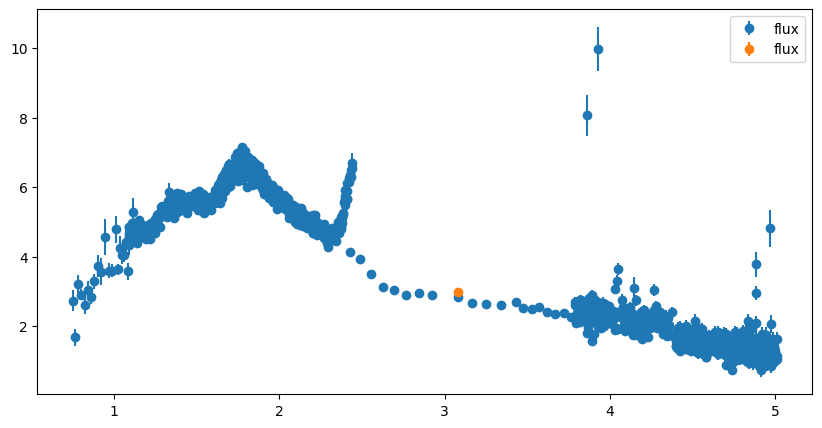

In [13]:
cpu_result = Table.read("/data1/hbahk/spherex-cluster/codes/realworld/specphot_results_testgal_a2255.parquet")
cpu_result[1444]

wave = cpu_result["central_wavelength"]
flux = cpu_result["flux"]
ferr = cpu_result["flux_err"]

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
ax.errorbar(wave, flux, ferr, fmt="o", label="flux")
ax.errorbar(wave[1444], [2.9692042], [0.004599438255249691], fmt="o", label="flux")
ax.legend()
plt.show()

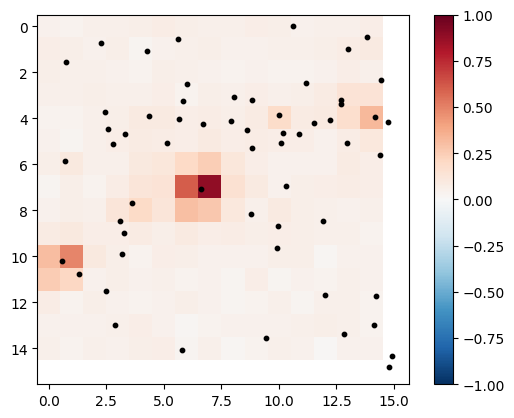

In [ ]:
plt.imshow(img-bkg, vmin=-1, vmax=1, cmap="RdBu_r")#, norm="log")
plt.colorbar()
plt.scatter(stab["x"], stab["y"], c="k", s=10)
# plt.imshow(flg, cmap="Reds", alpha=0.5)
# plt.imshow(np.isfinite(img-bkg), cmap="Reds", alpha=0.5)

In [31]:
trac_spherex.images[0].sky

ConstantSky(0.0423103)

In [36]:
result[0][0][i]

-0.047848135

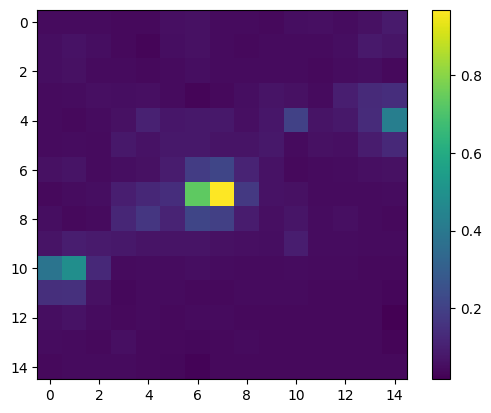

In [39]:
for i, src in enumerate(trac_spherex.catalog):
    src.brightness.setParam(0, result[0][0][i])
mod = trac_spherex.getModelImage(0)
plt.imshow(mod)#, vmin=-0.25, vmax=1.75)
plt.colorbar()

In [40]:
sky = trac_spherex.images[0].sky.getConstant()

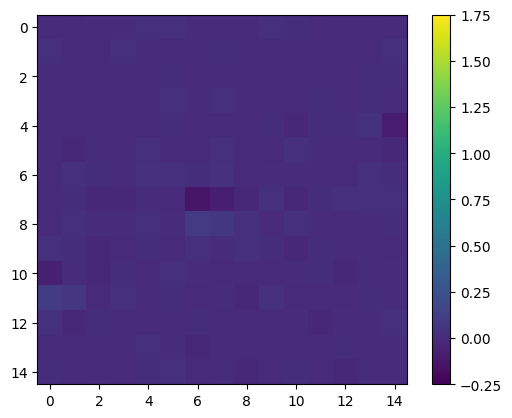

In [41]:
plt.imshow(img-bkg-mod, vmin=-0.25, vmax=1.75)
# plt.imshow(img-bkg-(mod-sky)*100-sky, vmin=-0.25, vmax=1.75)
plt.colorbar()

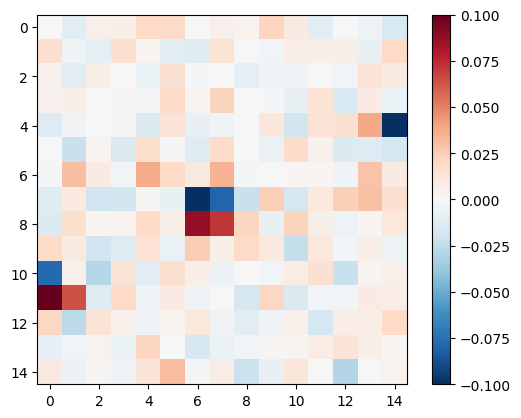

In [44]:
plt.imshow(img-bkg-mod, vmin=-0.1, vmax=0.1, cmap="RdBu_r")
plt.colorbar()

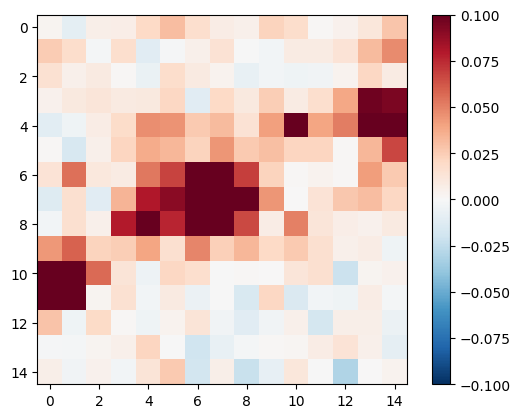

In [42]:
plt.imshow(img-bkg-sky, vmin=-0.1, vmax=0.1, cmap="RdBu_r")
plt.colorbar()

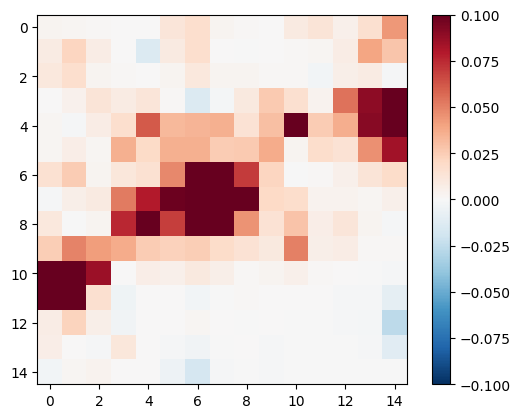

In [43]:
plt.imshow(mod-sky, vmin=-0.1, vmax=0.1, cmap="RdBu_r")
plt.colorbar()

In [14]:
from tractor.utils import BaseParams, ParamList, MultiParams, ArithmeticParams
from tractor import ducks

class AstropyWCS(BaseParams, ducks.WCS):
    '''
    A Tractor WCS implementation that wraps an astropy.wcs.WCS object.
    '''
    def __init__(self, wcs, origin=0):
        '''
        wcs: an astropy.wcs.WCS object.
        origin: 0 or 1.
          Tractor uses 0-based pixel coordinates (center of first pixel is 0,0).
          FITS uses 1-based (center of first pixel is 1,1).
          If `origin` is 0, input (x,y) to positionToPixel/pixelToPosition
          are treated as 0-based (numpy-like) coordinates.
        '''
        self.wcs = wcs
        self.origin = origin

    def hashkey(self):
        # WCS objects are mutable and don't hash nicely; use the header string representation.
        return ('AstropyWCS', self.wcs.to_header_string(), self.origin)

    def positionToPixel(self, pos, src=None):
        if hasattr(pos, 'ra') and hasattr(pos, 'dec'):
            ra, dec = pos.ra, pos.dec
        elif hasattr(pos, 'x') and hasattr(pos, 'y'):
             # Already pixel? This shouldn't happen for a celestial WCS usually.
             return pos.x, pos.y
        else:
             raise ValueError("Unknown position type: %s" % type(pos))

        # astropy.wcs.all_world2pix handles scalar inputs
        x, y = self.wcs.all_world2pix(ra, dec, self.origin)
        return float(x), float(y)

    def pixelToPosition(self, x, y, src=None):
        ra, dec = self.wcs.all_pix2world(x, y, self.origin)
        return RaDecPos(ra, dec)

    def cdAtPixel(self, x, y):
        '''
        Returns the CD matrix at pixel x,y:
        [ [ dRA/dx * cos(Dec), dRA/dy * cos(Dec) ],
          [ dDec/dx          , dDec/dy           ] ]
        '''
        # We compute derivatives numerically to handle distortions correctly.
        delta = 1e-4
        r0, d0 = self.wcs.all_pix2world(x, y, self.origin)
        r1, d1 = self.wcs.all_pix2world(x + delta, y, self.origin)
        r2, d2 = self.wcs.all_pix2world(x, y + delta, self.origin)

        # Derivatives of RA, Dec with respect to x, y
        dRa_dx = (r1 - r0) / delta
        dDec_dx = (d1 - d0) / delta
        dRa_dy = (r2 - r0) / delta
        dDec_dy = (d2 - d0) / delta

        cosdec = np.cos(np.deg2rad(d0))

        cd = np.array([
            [dRa_dx * cosdec, dRa_dy * cosdec],
            [dDec_dx        , dDec_dy        ]
        ])
        return cd

    def pixscale_at(self, x, y):
        # Return sqrt(det(CD matrix)) * 3600
        cd = self.cdAtPixel(x, y)
        det = np.abs(np.linalg.det(cd))
        return 3600. * np.sqrt(det)

    def shifted(self, dx, dy):
        # Create a copy and shift the CRPIX.
        # CRPIX is the pixel coordinate of the reference point.
        # If we shift the image window by (dx, dy),
        # a pixel (x,y) in the new image corresponds to (x+dx, y+dy) in the original.
        # The WCS should map (0,0) in new image to same sky as (dx, dy) in old image.
        # Old WCS: P_old -> Sky.  P_old = P_new + shift.
        # New WCS should map P_new -> Sky = WCS(P_new + shift).
        # Typically this is done by modifying CRPIX.
        # CRPIX_new = CRPIX_old - shift.

        wcs_copy = self.wcs.deepcopy()
        # wcs.wcs.crpix is usually 1-based (FITS convention) but stored as array.
        # Subtracting shifts works regardless of origin if we are just shifting the grid.
        wcs_copy.wcs.crpix[0] -= dx
        wcs_copy.wcs.crpix[1] -= dy

        # Also need to handle SIP distortions if present?
        # If SIP is present, crpix is used in the linear transformation before SIP.
        # However, SIP coefficients depend on pixel coordinates relative to CRPIX.
        # If we change CRPIX, we are changing where the origin of SIP polynomial is?
        # Wait. SIP is usually defined relative to CRPIX.
        # If we change CRPIX, we effectively move the reference point on the image.
        # This is correct for a crop/shift. The "physical" reference point stays at the same sky location,
        # but its pixel coordinate in the new image is different.

        return AstropyWCS(wcs_copy, origin=self.origin)

In [15]:
e1, e2 = tab["shape_e1"], tab["shape_e2"]
e = np.hypot(e1, e2)
ab = (1 - e) / (1 + e)  # axis ratio = b/a
# phi = -np.rad2deg(np.arctan2(e2, e1) / 2)
phi = 0.5 * np.rad2deg(np.arctan2(e2, e1))
phi = (phi + 180.0) % 180.0
tab["shape_phi"] = phi
tab["shape_ab"] = ab

In [16]:
from tqdm import trange
# open the output file
start_time = time.time()
hdul = fits.open(output_filename)
end_time = time.time()
print(f"Time to open the output file: {end_time - start_time} seconds")

start_time = time.time()
cutout_info = Table(hdul[1].data)
end_time = time.time()
print(f"Time to read the cutout info: {end_time - start_time} seconds")


nframes = (len(hdul) - 2) // 6
tims = []

# for i in trange(nframes):
for i in trange(100):
    img_idx = 2 + i * 6
    flg_idx = img_idx + 1
    var_idx = img_idx + 2
    bkg_idx = img_idx + 3
    psf_idx = img_idx + 4
    psf_lookup_idx = img_idx + 5
    
    img = hdul[img_idx].data
    hdr = hdul[img_idx].header
    wcs = WCS(hdr)
    
    wcs_tractor = AstropyWCS(wcs)

    flg = hdul[flg_idx].data
    var = hdul[var_idx].data
    bkg = hdul[bkg_idx].data

    invvar = 1 / var
    mask = flg & MASKBITS != 0
    invvar[mask] = 0

    psf_cube = hdul[psf_idx].data
    psf_lookup = hdul[psf_lookup_idx].data

    gx, gy = cutout_info["x"][i], cutout_info["y"][i]
    zoneid = get_nearest_psf_zone_index(gx, gy, psf_lookup)
    zidx = np.where(psf_lookup["zone_id"] == zoneid)[0][0]
    psf = psf_cube[zidx]

    psf_tractor = FluxNormalizedPixelizedPSF(psf, sampling=0.1)

    # get the pixel coordinates of the target
    # TODO: this is per-image, but we should handle this per-source with unified window
    tx, ty = wcs.world_to_pixel(tco)

    tinside = (tx > -0.5) & (tx < img.shape[1]+0.5) & (ty > -0.5) & (ty < img.shape[0]+0.5)

    stab = tab#[tinside]
    
    tim = tractor.Image(
        data=img - bkg,
        invvar=invvar,
        psf=psf_tractor,
        wcs=wcs_tractor,
        photocal=LinearPhotoCal(1.0),
        sky=ConstantSky(0.0),
    )

    tim.freezeAllRecursive()
    tim.thawPathsTo("sky")
    
    tims.append(tim)


Time to open the output file: 0.0019538402557373047 seconds
Time to read the cutout info: 0.008002281188964844 seconds


100%|██████████| 100/100 [00:01<00:00, 54.13it/s]


In [17]:

tractor_source_list = []
for row in stab:
    _flux = Flux(np.random.uniform(high=1))
    if row["shape_r"] == 0:
        # _src = PointSource(PixPos(row["x"], row["y"]), _flux)
        _src = PointSource(RaDecPos(row["ra"], row["dec"]), _flux)
    else:
        phi_img = sky_pa_to_pixel_pa(wcs, row["ra"], row["dec"], row["shape_phi"], d_arcsec=1.0, y_down=False)
        
        _src = SPHERExSersicGalaxy(
            RaDecPos(row["ra"], row["dec"]),
            _flux,
            GalaxyShape(row["shape_r"], row["shape_ab"], phi_img),
            SersicIndex(row["sersic"]),
        )

    _src.freezeAllRecursive()
    _src.thawParam("brightness")

    if row["shape_r"] > 0:
        if THAW_SHAPE:
            _src.thawPathsTo("re")
            _src.thawPathsTo("ab")
            _src.thawPathsTo("phi")

    if THAW_POSITIONS:
        _src.thawPathsTo("x")
        _src.thawPathsTo("y")

    tractor_source_list.append(_src)
    
trac_spherex = tractor.Tractor(tims[:25], tractor_source_list)



In [18]:
result = optimize_fluxes(trac_spherex, oversample_rendering=True, return_variances=True, fit_background=True)

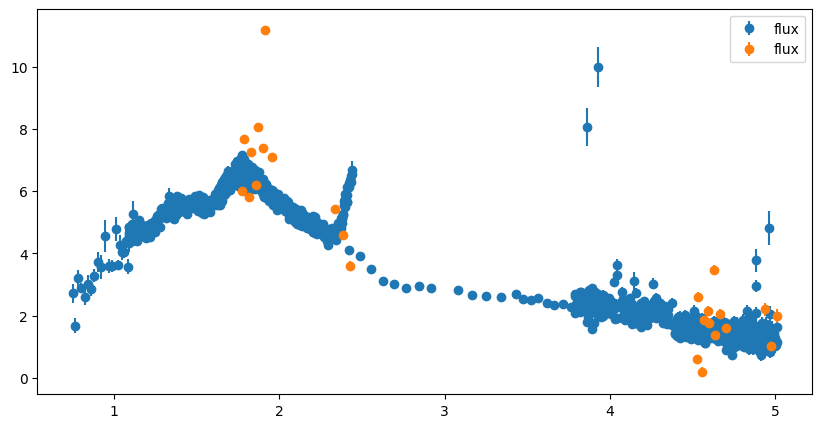

In [22]:
flux = np.array(result)[:, 0, main_idx] * PIX_SR * 1.0e9
ferr = np.sqrt(np.array(result)[:, 1, main_idx]) * PIX_SR * 1.0e9
wave = cutout_info["central_wavelength"][:25]


fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
ax.errorbar(cpu_result["central_wavelength"], cpu_result["flux"], cpu_result["flux_err"], fmt="o", label="flux")
ax.errorbar(wave, flux, ferr, fmt="o", label="flux")
ax.legend()
plt.show()